# 🎙️ Week 6 · Mini Project 3: Multimodal Participation in the Studio

**EDIS 8100: Teaching and Learning Analytics**

Session: Wednesday, September 30, 2026 · Estimated time: about 30 minutes to launch in class, 2 to 3 hours to finish

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

Twenty-four studio groups of five students met eight times. A microphone array logged who spoke and for how long, a camera pipeline logged gestures and where people looked, and the shared workspace logged chat messages and document edits. This week you ask a deceptively simple question: **who participated?**

The answer depends on which sensor you trust, and that is the whole point.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Build per-student participation profiles across audio, video, and digital modalities, and explain why raw units have to be put on a common scale before they can be compared.
2. Compute and interpret the Gini coefficient of speaking time for a small group, including what it hides.
3. Disaggregate a multimodal participation measure by student background, and say precisely what a single-modality measure would have gotten wrong.
4. Link participation structure to a group product and state, in writing, the limits of that link.

## How this notebook works (read this if you are new to code)

- Run the cells from top to bottom. Click a cell and press **Shift+Enter**, or use the play button on the left of the cell.
- **Nothing here can break your computer.** This notebook writes only into its own temporary folder, and the data are invented.
- If something looks broken, the fix is almost always **Runtime > Restart session and run all** (in Colab) or **Kernel > Restart & Run All** (in Jupyter). Start from the top again and it will rebuild itself.
- You are never asked to write code from a blank page. The cells marked **✏️ Your turn** ask you to change a value that already has a working default, so the notebook runs correctly even if you change nothing.
- Red text is not always an error. If you see a `Warning`, keep going.

## ⚙️ Setup: run the next cell first

The cell below builds this week's four datasets inside this runtime, so there is nothing to download and nothing to log into. It takes a couple of seconds.

Every student, every second of speaking time, and every chat message in these files is **synthetic**. We invented this course precisely so that we can practice reading participation data without surveilling a single real person. The ask in return: treat the data as if they were real, because the habits you build here are the habits you will carry into a room with actual students in it.

In [1]:
# NOTE: This cell is long. It is the data generator, and it lives here so that the notebook
# works in Colab with no downloads and no login. You do NOT need to read it.
# Click the arrow in the margin to collapse it, run it once, and move on.

"""EDIS 8100 data generation, the subset needed for week06.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GROUP_CHAT = SEED + 4
SEED_MMLA = SEED + 5
SEED_ARTIFACTS = SEED + 6
SEED_STUDIO_CHAT = SEED + 20
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
WEEK_TOPICS = {
    1: "memory",
    2: "spacing",
    3: "metacognition",
    4: "motivation",
    5: "collaboration",
    6: "note-taking",
    7: "sleep",
    8: "test anxiety",
}
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def gini(values) -> float:
    """Gini coefficient of a nonnegative vector. 0 means perfectly equal."""
    v = np.sort(np.asarray(values, dtype="float64"))
    v = np.clip(v, 0, None)
    n = v.size
    total = v.sum()
    if n == 0 or total <= 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float((2.0 * np.sum(idx * v)) / (n * total) - (n + 1.0) / n)
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    # Higher values shift a student's submissions closer to the deadline.
    short_lead_time = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the week 3 model leans on when it
    # reproduces the field's "at-risk" construct.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the week 3 model of that construct go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    concentrated_schedule = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (concentrated_schedule == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: a subgroup whose tutor logs contain runs of hint requests a few
    # seconds apart. The generator plants the LOG PATTERN, not a motive.
    rapid_hint_flag = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    rapid_hint_flag[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "short_lead_time": short_lead_time,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "concentrated_schedule": concentrated_schedule,
            "rapid_hint_flag": rapid_hint_flag,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
def _studio_chat_counts(students: pd.DataFrame):
    """Messages and substantive idea units per student per studio session.

    Drawn once from a dedicated stream so that group_chat.csv and mmla_studio.csv
    tell the same story about who typed what. Multilingual students send at least
    as many messages and a higher share of substantive ones, which is half of P5.
    """
    rng = np.random.default_rng(SEED_STUDIO_CHAT)
    n = len(students)
    chat_prop = _z(students["chat_propensity"].to_numpy())
    multilingual = students["multilingual"].to_numpy()
    ability = students["ability"].to_numpy()

    lam = np.exp(1.72 + 0.38 * chat_prop + 0.19 * multilingual)
    p_sub = np.clip(0.34 + 0.055 * multilingual + 0.05 * ability, 0.10, 0.85)

    n_msgs = np.zeros((n, N_WEEKS), dtype=int)
    n_sub = np.zeros((n, N_WEEKS), dtype=int)
    for s in range(N_WEEKS):
        session_factor = float(rng.uniform(0.82, 1.22))
        msgs = rng.poisson(lam * session_factor)
        n_msgs[:, s] = msgs
        n_sub[:, s] = rng.binomial(msgs, p_sub)
    return n_msgs, n_sub
CHAT_LEADS = ["", "", "", "ok ", "alright ", "so ", "hey ", "wait ", "yeah ", "hmm ", "right ", "oh "]
CHAT_TAGS = [
    "", "", "", "", "?", " right", " does that track", " if that works for everyone",
    " what do you think", " or am i off", " lol", " sorry if that is obvious",
]
CHAT_PARTS = [
    "part 1", "part 2", "part 3", "the intro", "the summary", "the second question",
    "the examples", "the last section", "the wrap up", "the definitions", "the counterargument",
]
CHAT_THINGS = [
    "the rubric", "the prompt", "the reading", "the doc link", "the slide", "our notes",
    "the question", "the example", "the table", "the handout", "the transcript",
]
CHAT_VERBS = ["start", "open", "share", "set up", "clean up", "reorganize"]
CHAT_NUMS = ["two", "three", "four", "five", "ten", "fifteen", "twenty"]
CHAT_COORDINATION = [
    "{lead}who is taking notes today{tag}",
    "{lead}i can {verb} the doc{tag}",
    "{lead}i'll take {part}{tag}",
    "{lead}can someone paste {thing}{tag}",
    "{lead}we have {num} minutes left{tag}",
    "{lead}let's split this {num} ways{tag}",
    "{lead}i'm adding {thing} to the doc{tag}",
    "{lead}who wants to present back{tag}",
    "{lead}should we outline first{tag}",
    "{lead}let's timebox this to {num} minutes{tag}",
    "{lead}i'll write up {part}{tag}",
    "{lead}moving {thing} into the doc now{tag}",
    "{lead}does everyone have {thing} open{tag}",
    "{lead}i can present if nobody else wants to{tag}",
    "{lead}putting {thing} at the top of the doc{tag}",
    "{lead}can we come back to {part} in a sec{tag}",
    "{lead}i lost {thing} again sorry{tag}",
    "{lead}sharing my screen now{tag}",
    "{lead}let's each take {num} minutes to write first{tag}",
    "{lead}someone should own {part}{tag}",
]
CHAT_SOCIAL = [
    "{lead}good point{tag}", "{lead}yes exactly{tag}", "{lead}that makes sense{tag}",
    "{lead}agreed{tag}", "{lead}oh interesting{tag}", "{lead}really{tag}",
    "{lead}that is a great way to put it{tag}", "{lead}same here honestly{tag}",
    "{lead}you two are on a roll{tag}", "{lead}my wifi dropped sorry{tag}",
    "{lead}i'm back{tag}", "{lead}thanks for waiting{tag}", "{lead}this is fun actually{tag}",
    "{lead}i'm following now{tag}", "{lead}no worries{tag}", "{lead}brb one sec{tag}",
    "{lead}that made me laugh{tag}", "{lead}i'm convinced{tag}",
    "{lead}hi all{tag}", "{lead}running two minutes late{tag}",
    "{lead}nice{tag}", "{lead}fair enough{tag}", "{lead}love that{tag}",
]
CHAT_CLARIFY = [
    "{lead}which {thing} are we on{tag}",
    "{lead}can you say more about that{tag}",
    "{lead}sorry can you repeat that{tag}",
    "{lead}i'm not sure i follow{tag}",
    "{lead}can you give an example{tag}",
    "{lead}do you mean {thing} or the other one{tag}",
    "{lead}hold on let me reread {thing}{tag}",
    "{lead}what does that term mean again{tag}",
    "{lead}are we answering question {num} or the next one{tag}",
    "{lead}is that the same as what we said before{tag}",
    "{lead}i missed that last bit{tag}",
    "{lead}where is that in {thing}{tag}",
]
CHAT_HEDGES = [
    "", "", "", "i think ", "maybe ", "honestly ", "so ", "not sure, but ",
    "from the reading, ", "for the doc, ", "my read is ", "counterpoint, ",
]
CHAT_SUBSTANTIVE = {
    "memory": [
        "i think recall beats rereading for us because the exam is all application",
        "the forgetting curve thing only worked for me when i spaced it out",
        "recognizing it in the notes is not the same as producing it",
        "our example should be the blank page recall one",
        "chunking is basically why the experts in the study looked faster",
        "maybe we say encoding decides which cues work later",
        "the testing effect showed up even in the ungraded condition which is the interesting part",
        "cues matter as much as effort when you are trying to bring something back",
        "we could open with the difference between recognizing and producing",
    ],
    "spacing": [
        "four short sessions beat one long one even at equal time",
        "interleaving felt terrible and my scores went up",
        "cramming is borrowing from next month",
        "we should say the optimal gap depends on the retention interval",
        "our counterexample is the student who cannot control their schedule",
        "the calendar is the intervention honestly",
        "blocked practice makes you feel fluent and that is the trap",
        "the lag effect is the part i did not know before this week",
        "how long you need to remember it should set the gap",
    ],
    "metacognition": [
        "my confidence ratings were about eight points too high every time",
        "monitoring only matters if it changes the next action",
        "the illusion of fluency is the whole problem with rereading",
        "we could ask students to predict their score before submitting",
        "reflection has to point at something you will actually do",
        "calibration is the word we want in the summary",
        "self report is the measure and also the thing we are trying to fix",
        "overconfidence is worst on the material that feels familiar",
        "a study plan nobody follows is not a plan",
    ],
    "motivation": [
        "cost is the piece everyone skips in expectancy value",
        "self efficacy comes from mastery experiences not pep talks",
        "a student working thirty hours is not lacking grit",
        "we should distinguish interest you arrive with from interest you develop",
        "performance goals hold up until the first bad grade",
        "autonomy matters most when the task is hard",
        "our design should let students pick the topic",
        "attribution after a bad grade is where self efficacy gets decided",
        "utility value and interest are not the same thing",
    ],
    "collaboration": [
        "equal talk time is not equal contribution",
        "we should write silently first then discuss",
        "the quietest person had the key objection last week",
        "transactive means building on the previous turn not just adding",
        "roles help until people stop listening outside their role",
        "our dashboard should not rank individuals in the group",
        "group grades hide huge variation inside the group",
        "socially shared regulation is the term for what our group does badly",
        "who gets listened to is a design question not a personality one",
    ],
    "note-taking": [
        "complete notes usually mean unprocessed notes",
        "the encoding benefit happens while you write",
        "the margin questions became my whole study guide",
        "one page per lecture forced me to choose",
        "the concept map showed two ideas i had kept separate",
        "we should recommend a revision pass not just a format",
        "if slides are posted the note strategy should change",
        "selectivity while listening is the actual skill",
        "we should ask what the notes are for before we recommend a format",
    ],
    "sleep": [
        "the last two hours of studying cost more than they return",
        "consolidation is part of learning not a break from it",
        "attention lapses show up before you feel tired",
        "we should be careful about collecting sleep data at all",
        "fixed wake time helped me more than total hours did",
        "an eight am class fights most undergrad circadian rhythms",
        "sleep advice assumes a schedule many students do not control",
        "one more hour of studying versus one more sleep cycle is the real tradeoff",
        "framing sleep as a study strategy landed better with my students",
    ],
    "test anxiety": [
        "worry eats the working memory the test is measuring",
        "reappraisal did not calm me down but it helped my score",
        "low stakes practice testing lowers the stakes of the real one",
        "maybe the assessment design is the problem not the student",
        "the worry component predicts scores better than the physical symptoms",
        "we should say frequent low stakes quizzes carefully",
        "an early warning email to an anxious student could backfire",
        "one high stakes exam measures composure as much as knowledge",
        "treating arousal as information is the reappraisal move",
    ],
}
def _compose_chat(rng, topic: str, kind: str) -> str:
    """One short chat message. Slots keep the register natural without repeating."""
    lead = str(rng.choice(CHAT_LEADS))
    tag = str(rng.choice(CHAT_TAGS))
    if kind == "substantive":
        body = str(rng.choice(CHAT_SUBSTANTIVE[topic]))
        hedge = str(rng.choice(CHAT_HEDGES))
        return (lead + hedge + body + tag).strip()

    roll = rng.random()
    if roll < 0.42:
        template = str(rng.choice(CHAT_COORDINATION))
    elif roll < 0.76:
        template = str(rng.choice(CHAT_SOCIAL))
    else:
        template = str(rng.choice(CHAT_CLARIFY))
    if roll >= 0.42 and roll < 0.76 and rng.random() < 0.65:
        tag = ""  # short reactions rarely carry a trailing tag
    return template.format(
        lead=lead,
        tag=tag,
        part=str(rng.choice(CHAT_PARTS)),
        thing=str(rng.choice(CHAT_THINGS)),
        verb=str(rng.choice(CHAT_VERBS)),
        num=str(rng.choice(CHAT_NUMS)),
    ).strip()
def make_group_chat(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Backchannel chat from the eight weekly studio sessions.

    Short chat register on purpose, so week 5 can contrast it with the longer,
    more formal forum posts. Message counts match mmla_studio.csv exactly.
    """
    rng = np.random.default_rng(SEED_GROUP_CHAT)
    students = make_students(write=False)
    n_msgs, n_sub = _studio_chat_counts(students)

    sid = students["student_id"].to_numpy()
    gid = students["group_id"].to_numpy()

    rows = []
    counter = 0
    for s in range(N_WEEKS):
        week = s + 1
        topic = WEEK_TOPICS[week]
        # Studio meets Thursday of each course week, 4:00 to 5:30 PM.
        session_start_s = ((week - 1) * 7 + 3) * DAY_S + 16 * 3600
        for i in range(len(students)):
            total = int(n_msgs[i, s])
            if total == 0:
                continue
            subs = int(n_sub[i, s])
            kinds = ["substantive"] * subs + ["other"] * (total - subs)
            rng.shuffle(kinds)
            offsets = np.sort(rng.uniform(60, 88 * 60, total))
            for kind, off in zip(kinds, offsets):
                text = _compose_chat(rng, topic, kind)
                counter += 1
                rows.append(
                    {
                        "group_id": gid[i],
                        "session_id": f"studio_{week}",
                        "student_id": sid[i],
                        "_secs": session_start_s + float(off),
                        "text": text,
                    }
                )

    df = pd.DataFrame(rows).sort_values("_secs", kind="stable").reset_index(drop=True)
    df["message_id"] = [f"M{i + 1:05d}" for i in range(len(df))]
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["message_id", "group_id", "session_id", "student_id", "timestamp", "text"]]
    if write:
        df.to_csv(_outpath(outdir, "group_chat.csv"), index=False)
    return df
def make_mmla(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """One row per student per studio session, across five modalities.

    P5 lives here: multilingual students hold the floor less, and contribute at
    least as much through chat, idea units, and document edits. Anyone who reads
    only speaking_time_s will misdescribe them.

    P9 also starts here: groups differ in how evenly speaking time is spread, and
    studio_artifacts.csv scores the products those groups made.
    """
    rng = np.random.default_rng(SEED_MMLA)
    students = make_students(write=False)
    n_msgs, n_sub = _studio_chat_counts(students)

    sid = students["student_id"].to_numpy()
    gid = students["group_id"].to_numpy()
    talk = students["talkativeness"].to_numpy()
    multilingual = students["multilingual"].to_numpy()
    doc_prop = _z(students["doc_propensity"].to_numpy())

    group_names = [f"G{g + 1:02d}" for g in range(N_GROUPS)]
    members = {g: np.where(gid == g)[0] for g in group_names}

    # How evenly the floor is shared in each group. Low alpha means one or two
    # people dominate every session.
    group_alpha = np.exp(rng.normal(1.30, 0.62, N_GROUPS))
    group_alpha = np.clip(group_alpha, 0.8, 14.0)

    rows = []
    for s in range(N_WEEKS):
        session_id = f"studio_{s + 1}"
        for g_i, g in enumerate(group_names):
            idx = members[g]
            w = np.exp(0.55 * talk[idx] - 0.26 * multilingual[idx])
            alpha = group_alpha[g_i] * w / w.mean()
            shares = rng.dirichlet(np.clip(alpha, 0.15, None))

            total_speech = float(rng.normal(3050, 260))
            total_turns = int(rng.integers(150, 260))

            # Even a student who barely speaks says something, so nobody is a flat zero.
            speaking = np.round(np.maximum(shares * total_speech, rng.uniform(3, 22, len(idx))), 1)
            turns = np.maximum(1, rng.poisson(np.clip(shares * total_turns, 0.7, None)))
            avg_turn = np.round(speaking / turns, 1)
            interruptions = rng.poisson(np.clip(0.6 + 9.0 * shares, 0.05, None))
            gaze_peer = np.clip(
                rng.normal(38 + 26 * (shares - 0.2) + 3.0 * multilingual[idx], 6.0), 8, 72
            )
            gaze_material = np.clip(rng.normal(74 - gaze_peer * 0.55, 7.0), 10, 70)
            over = np.maximum(0.0, gaze_peer + gaze_material - 94.0)
            gaze_material = gaze_material - over
            gestures = rng.poisson(np.clip(5 + 42 * shares, 0.5, None))
            doc_edits = rng.poisson(
                np.clip(3.4 + 2.4 * doc_prop[idx] + 1.2 * multilingual[idx], 0.4, None)
            )

            for j, i in enumerate(idx):
                rows.append(
                    {
                        "session_id": session_id,
                        "group_id": g,
                        "student_id": sid[i],
                        "speaking_time_s": float(speaking[j]),
                        "num_turns": int(turns[j]),
                        "interruptions": int(interruptions[j]),
                        "avg_turn_length_s": float(avg_turn[j]),
                        "gaze_peer_pct": round(float(gaze_peer[j]), 1),
                        "gaze_material_pct": round(float(gaze_material[j]), 1),
                        "gesture_count": int(gestures[j]),
                        "chat_messages": int(n_msgs[i, s]),
                        "doc_edits": int(doc_edits[j]),
                        "idea_units_chat": int(n_sub[i, s]),
                    }
                )

    df = pd.DataFrame(rows)
    df = df.sort_values(["session_id", "group_id", "student_id"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "mmla_studio.csv"), index=False)
    return df
def make_studio_artifacts(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Rubric score, 1 to 10, for the product each group made in each session.

    P9: groups whose speaking time is spread evenly (low Gini) produce better
    rated artifacts than groups where one or two voices dominate. Group ability
    and the amount of substantive chat also matter, so the relationship is real
    but never clean.
    """
    rng = np.random.default_rng(SEED_ARTIFACTS)
    students = make_students(write=False)
    mmla = make_mmla(write=False)

    group_ability = (
        students.assign(a=students["ability"]).groupby("group_id")["a"].mean().to_dict()
    )

    grouped = mmla.groupby(["group_id", "session_id"])
    rows = []
    for (g, s), sub in grouped:
        g_ini = gini(sub["speaking_time_s"].to_numpy())
        idea = float(sub["idea_units_chat"].sum())
        rows.append({"group_id": g, "session_id": s, "gini": g_ini, "idea": idea, "ga": group_ability[g]})

    frame = pd.DataFrame(rows)
    idea_z = _z(frame["idea"].to_numpy())
    gini_c = frame["gini"].to_numpy() - frame["gini"].mean()

    raw = (
        6.5
        - 5.0 * gini_c
        + 0.62 * frame["ga"].to_numpy()
        + 0.42 * idea_z
        + rng.normal(0, 1.15, len(frame))
    )
    frame["artifact_score"] = np.round(np.clip(raw, 1.0, 10.0), 1)

    df = frame[["group_id", "session_id", "artifact_score"]].copy()
    df["_k"] = df["session_id"].str.replace("studio_", "", regex=False).astype(int)
    df = df.sort_values(["_k", "group_id"], kind="stable").drop(columns="_k").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "studio_artifacts.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_mmla(outdir=outdir)
    make_studio_artifacts(outdir=outdir)
    make_group_chat(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)

Data ready. Files created in ./data:
   group_chat.csv
   mmla_studio.csv
   students.csv
   studio_artifacts.csv


## 📊 1. Four files, four grains

Before any analysis, know what one row of each file means. Getting the **grain** wrong is the most common way a multimodal analysis goes quietly wrong: it is very easy to average an average and end up describing nobody.

- `students.csv`: one row per student (120 students).
- `mmla_studio.csv`: one row **per student per studio session** (120 students x 8 sessions = 960 rows). This is the multimodal file.
- `studio_artifacts.csv`: one row per group per session (24 x 8 = 192 rows), holding the rubric score for what the group produced that day.
- `group_chat.csv`: one row per chat message.

Run the next cell to load them and confirm those shapes for yourself.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.width', 130)
pd.set_option('display.max_columns', 40)

students  = pd.read_csv('data/students.csv')
mmla      = pd.read_csv('data/mmla_studio.csv')
artifacts = pd.read_csv('data/studio_artifacts.csv')
chat      = pd.read_csv('data/group_chat.csv')

print('students.csv         ', students.shape, '  one row per student')
print('mmla_studio.csv      ', mmla.shape, '  one row per student per studio session')
print('studio_artifacts.csv ', artifacts.shape, '  one row per group per session')
print('group_chat.csv       ', chat.shape, '  one row per chat message')
print()
print('Sessions :', ', '.join(sorted(mmla['session_id'].unique())))
print('Groups   :', mmla['group_id'].nunique(), 'studio groups')
print('Group size:', sorted(mmla.groupby(['group_id', 'session_id']).size().unique()), 'students per group per session')
print('Attendance: every student has a row in every session?',
      (mmla.groupby('student_id').size() == 8).all())

mmla.head()

students.csv          (120, 9)   one row per student
mmla_studio.csv       (960, 13)   one row per student per studio session
studio_artifacts.csv  (192, 3)   one row per group per session
group_chat.csv        (6379, 6)   one row per chat message

Sessions : studio_1, studio_2, studio_3, studio_4, studio_5, studio_6, studio_7, studio_8
Groups   : 24 studio groups
Group size: [5] students per group per session
Attendance: every student has a row in every session? True


,session_id,group_id,student_id,speaking_time_s,num_turns,interruptions,avg_turn_length_s,gaze_peer_pct,gaze_material_pct,gesture_count,chat_messages,doc_edits,idea_units_chat
0,studio_1,G01,S030,438.6,32,1,13.7,34.5,47.5,15,5,1,1
1,studio_1,G01,S033,93.9,5,0,18.8,19.6,65.4,11,3,4,1
2,studio_1,G01,S038,57.2,3,1,19.1,35.9,55.2,5,9,2,3
3,studio_1,G01,S056,98.8,3,2,32.9,28.4,64.0,5,4,3,1
4,studio_1,G01,S076,2581.2,122,5,21.2,54.9,33.6,43,4,0,1


### 1.1 What each column actually saw

Ochoa (2022) describes multimodal learning analytics as a pipeline: physical signals are captured by sensors, turned into features, and only then interpreted as evidence about learning. Every step in that pipeline throws information away. `speaking_time_s` is not "engagement", it is seconds of detected floor time. `gesture_count` is not "enthusiasm", it is the number of hand movements a computer vision model decided to count.

The table below names the sensor stream behind each column and what a careless reader might assume it means. Keep the third column in view all week: it is where the trouble starts.

In [3]:
MODALITIES = ['speaking_time_s', 'num_turns', 'gesture_count', 'gaze_peer_pct',
              'chat_messages', 'doc_edits', 'idea_units_chat']

LABELS = {
    'speaking_time_s' : 'Speaking time',
    'num_turns'       : 'Turns',
    'gesture_count'   : 'Gestures',
    'gaze_peer_pct'   : 'Gaze at peers',
    'chat_messages'   : 'Chat messages',
    'doc_edits'       : 'Doc edits',
    'idea_units_chat' : 'Idea units',
}

STREAM = {
    'speaking_time_s' : 'audio (mic array)',
    'num_turns'       : 'audio (mic array)',
    'gesture_count'   : 'video (pose model)',
    'gaze_peer_pct'   : 'video (gaze model)',
    'chat_messages'   : 'digital (workspace log)',
    'doc_edits'       : 'digital (workspace log)',
    'idea_units_chat' : 'digital (coded chat)',
}

RISKY_READING = {
    'speaking_time_s' : 'read as "engagement"',
    'num_turns'       : 'read as "responsiveness"',
    'gesture_count'   : 'read as "enthusiasm"',
    'gaze_peer_pct'   : 'read as "attention to peers"',
    'chat_messages'   : 'read as "chattiness"',
    'doc_edits'       : 'read as "doing the work"',
    'idea_units_chat' : 'read as "good ideas"',
}

overview = mmla[MODALITIES].describe().T[['mean', 'std', 'min', '50%', 'max']].round(1)
overview.insert(0, 'sensor stream', [STREAM[m] for m in overview.index])
overview.insert(1, 'often (mis)read as', [RISKY_READING[m] for m in overview.index])
overview.index = [LABELS[m] for m in overview.index]
overview

,sensor stream,often (mis)read as,mean,std,min,50%,max
Speaking time,audio (mic array),"read as ""engagement""",614.2,440.8,4.7,535.2,2581.2
Turns,audio (mic array),"read as ""responsiveness""",40.6,30.4,1.0,35.0,188.0
Gestures,video (pose model),"read as ""enthusiasm""",13.5,6.9,0.0,12.0,52.0
Gaze at peers,video (gaze model),"read as ""attention to peers""",38.6,7.1,17.2,38.8,60.5
Chat messages,digital (workspace log),"read as ""chattiness""",6.6,3.6,0.0,6.0,25.0
Doc edits,digital (workspace log),"read as ""doing the work""",3.9,3.0,0.0,3.0,19.0
Idea units,digital (coded chat),"read as ""good ideas""",2.4,1.8,0.0,2.0,10.0


**Notice the units.** Speaking time is measured in seconds and runs to the thousands. Idea units are counted and rarely pass 10. Gaze is a percentage. You cannot add these together, and you cannot compare them, until you put them on a shared scale. That is the next step.

## 📊 2. From raw sensors to comparable profiles

To compare a student's speaking time against their document edits, we convert every modality to a **percentile rank** within the class: 90 means "higher than 90 percent of the 120 students on this measure". Percentiles discard the raw magnitude on purpose. They answer a specific question, "where does this person sit relative to their classmates", and nothing else.

First we average each student's eight sessions, so that one unusually loud Thursday does not define anyone. Then we rank.

In [4]:
# Average across the 8 sessions, then attach group and student background.
group_of = mmla[['student_id', 'group_id']].drop_duplicates()

profile = (mmla.groupby('student_id')[MODALITIES].mean().reset_index()
           .merge(group_of, on='student_id')
           .merge(students[['student_id', 'first_name', 'last_name',
                            'gender', 'first_gen', 'multilingual']], on='student_id'))

# Percentile rank (0 to 100) within the class, one per modality.
for m in MODALITIES:
    profile['pct_' + m] = profile[m].rank(pct=True).mul(100).round(1)

PCT_COLS = ['pct_' + m for m in MODALITIES]

print('profile shape:', profile.shape, ' (one row per student)')
profile[['student_id', 'first_name', 'group_id'] + MODALITIES].head().round(1)

profile shape: (120, 21)  (one row per student)


,student_id,first_name,group_id,speaking_time_s,num_turns,gesture_count,gaze_peer_pct,chat_messages,doc_edits,idea_units_chat
0,S001,Avery,G07,1249.2,76.0,21.2,43.3,4.9,3.0,2.2
1,S002,Hana,G04,655.8,51.9,14.1,37.4,5.1,1.4,1.5
2,S003,Tanvi,G19,158.2,11.0,6.5,31.8,5.1,1.1,1.6
3,S004,Jonas,G18,177.1,11.1,8.8,40.7,5.5,4.5,1.9
4,S005,Fatima,G24,400.9,24.8,11.8,33.6,3.0,5.5,1.1


### 2.1 Two students, one group, opposite profiles

Group G01 met eight times. Two of its members give us the week's central case. The table below shows their **season totals**, not averages, because the raw numbers are worth seeing before anything is normalized.

In [5]:
totals = (mmla.groupby('student_id')
          .agg(speaking_time_s=('speaking_time_s', 'sum'),
               num_turns=('num_turns', 'sum'),
               chat_messages=('chat_messages', 'sum'),
               doc_edits=('doc_edits', 'sum'),
               idea_units_chat=('idea_units_chat', 'sum'))
          .reset_index()
          .merge(students[['student_id', 'first_name', 'last_name', 'multilingual']], on='student_id'))

pair = totals[totals['student_id'].isin(['S038', 'S076'])].copy()
pair['speaking_minutes'] = (pair['speaking_time_s'] / 60).round(1)
pair[['student_id', 'first_name', 'last_name', 'multilingual', 'speaking_minutes',
      'num_turns', 'chat_messages', 'doc_edits', 'idea_units_chat']]

,student_id,first_name,last_name,multilingual,speaking_minutes,num_turns,chat_messages,doc_edits,idea_units_chat
37,S038,Solveig,Petrov,1,9.3,38,73,12,40
75,S076,Mikael,Vasquez,0,136.2,447,26,12,8


Across eight studio sessions, Mikael held the floor for well over two hours and left 8 substantive ideas in the chat. Solveig spoke for about nine minutes total and left 40. Feed only `speaking_time_s` to a dashboard and the dashboard calls one of them a star and the other a problem. Feed it substantive contribution to the shared workspace and the ranking flips. Neither student changed. The measure did.

The radar chart below puts all seven modalities on one picture. Each spoke is a percentile: the further from the center, the higher that student ranks in the class.

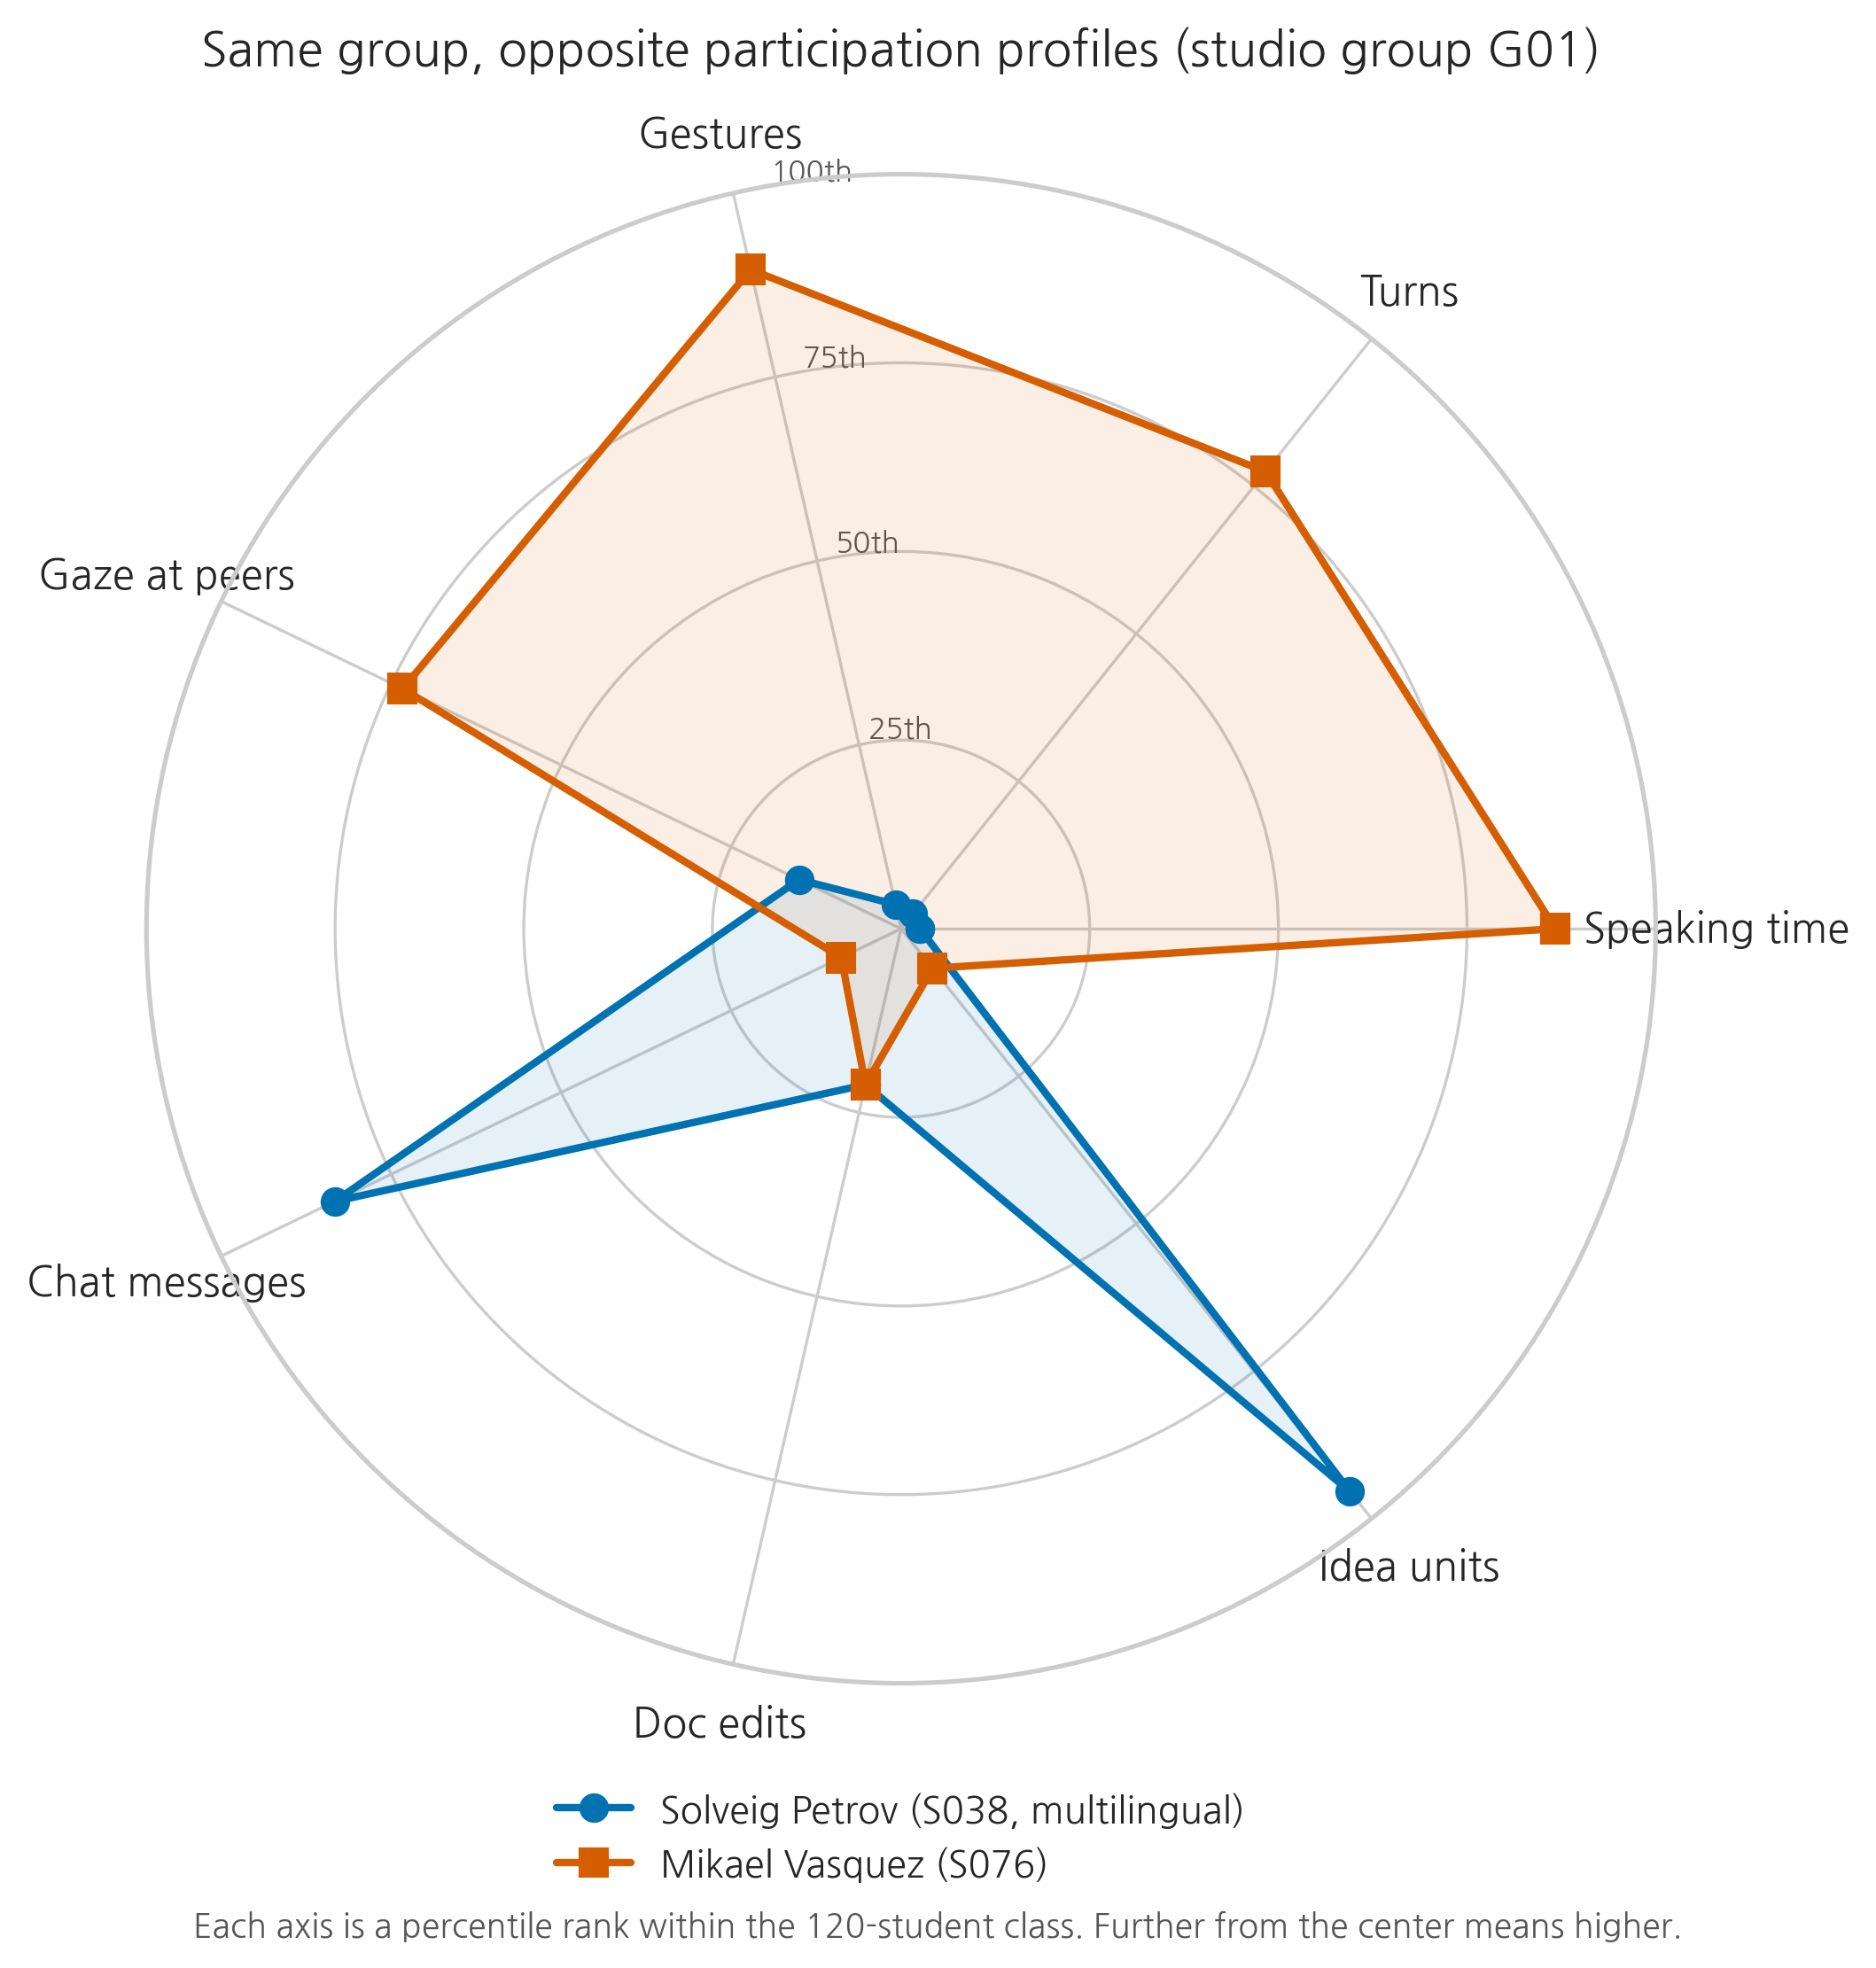

Percentile ranks used in the chart:
student  Speaking time  Turns  Gestures  Gaze at peers  Chat messages  Doc edits  Idea units
Solveig            2.5    2.5       3.3           15.0           83.3       21.2        95.4
 Mikael           86.7   77.5      89.6           73.3            8.8       21.2         6.7


In [6]:
# Colorblind-safe palette (Okabe-Ito). Line style and marker shape also differ,
# so the chart still reads if the colors are lost to printing or color vision deficiency.
SERIES_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9']
MARKERS       = ['o', 's', '^', 'D', 'v']
BLUE, ORANGE, GREY = '#0072B2', '#D55E00', '#8a8a8a'


def student_label(sid):
    r = profile.loc[profile['student_id'] == sid].iloc[0]
    tag = ', multilingual' if r['multilingual'] == 1 else ''
    return f"{r['first_name']} {r['last_name']} ({sid}{tag})"


def plot_radar(student_ids, title):
    n = len(MODALITIES)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7.4, 7.4), subplot_kw=dict(polar=True))
    for i, sid in enumerate(student_ids):
        row = profile.loc[profile['student_id'] == sid].iloc[0]
        vals = [row['pct_' + m] for m in MODALITIES]
        vals += vals[:1]
        ax.plot(angles, vals, color=SERIES_COLORS[i % 5], marker=MARKERS[i % 5],
                linewidth=2, markersize=7, label=student_label(sid))
        ax.fill(angles, vals, color=SERIES_COLORS[i % 5], alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([LABELS[m] for m in MODALITIES], fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25th', '50th', '75th', '100th'], fontsize=8, color='#555555')
    ax.set_rlabel_position(100)
    ax.grid(color='#cccccc', linewidth=0.8)
    ax.set_title(title, fontsize=13, pad=30)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=10)
    fig.text(0.5, 0.005,
             'Each axis is a percentile rank within the 120-student class. Further from the center means higher.',
             ha='center', fontsize=9, color='#555555')
    plt.tight_layout()
    plt.show()


plot_radar(['S038', 'S076'], 'Same group, opposite participation profiles (studio group G01)')

print('Percentile ranks used in the chart:')
show = profile[profile['student_id'].isin(['S038', 'S076'])][['first_name'] + PCT_COLS]
show.columns = ['student'] + [LABELS[m] for m in MODALITIES]
print(show.to_string(index=False))

**💬 Interpret before moving on.** Look at the two shapes. If a teacher dashboard displayed only the audio modalities (speaking time, turns), what would it say about Solveig? Write one sentence naming the decision a teacher might make on that basis, and one sentence naming what the chat and document columns would have told them instead.

### ✏️ Your turn 1: profile two other students

Change the two student IDs below and re-run. Any IDs from `S001` to `S120` work. The defaults already produce a chart, so the notebook runs fine if you leave them alone.

Suggestions if you want a fast start: `S015` and `S083` (both in group G10), or `S022` and `S072` (both in group G13).

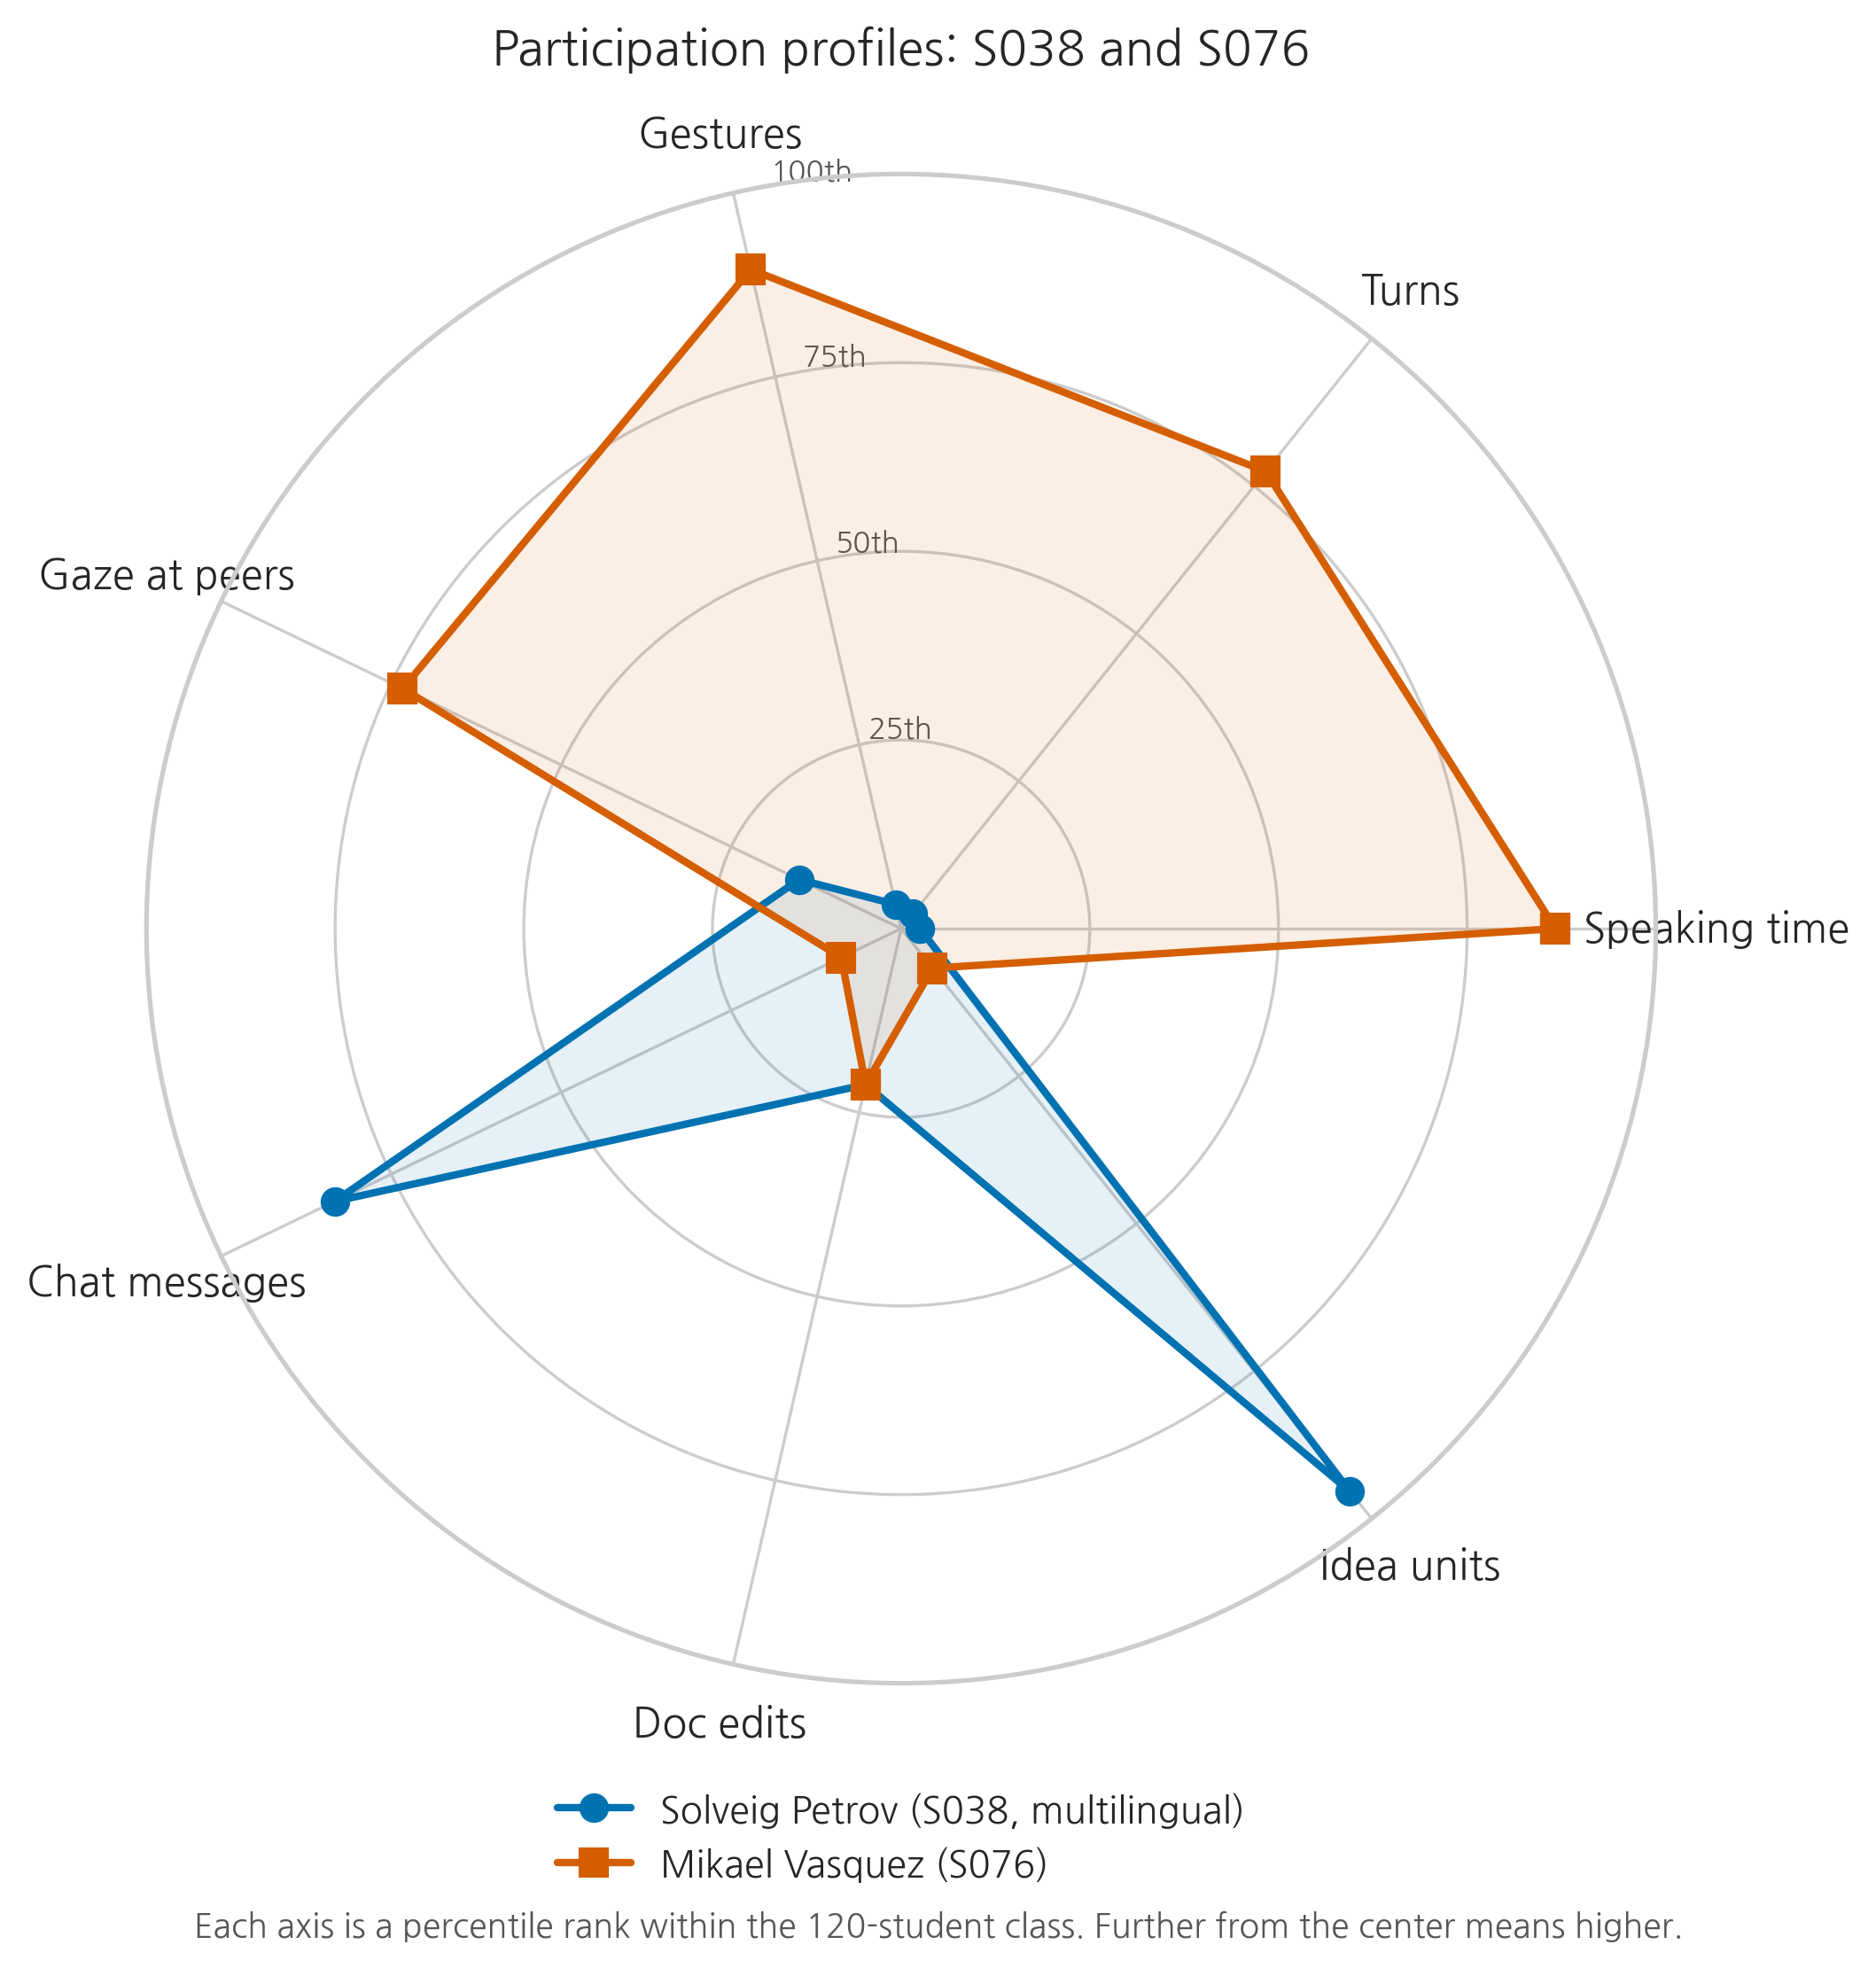

In [7]:
# TODO: change these two IDs and re-run the cell.
STUDENT_A = 'S038'
STUDENT_B = 'S076'

plot_radar([STUDENT_A, STUDENT_B], f'Participation profiles: {STUDENT_A} and {STUDENT_B}')

## 📊 3. A whole group at once: parallel coordinates

A radar chart is comfortable for two students and unreadable for five. A **parallel coordinates** plot solves the same problem differently: each modality gets its own vertical position on the x axis, and each student is one line crossing all of them. Crossing lines are the signal you are looking for. They mean the ranking of students changes depending on which modality you look at.

The function below draws one group. Multilingual students are drawn with dashed lines as well as their own color, so the distinction survives a black-and-white printout.

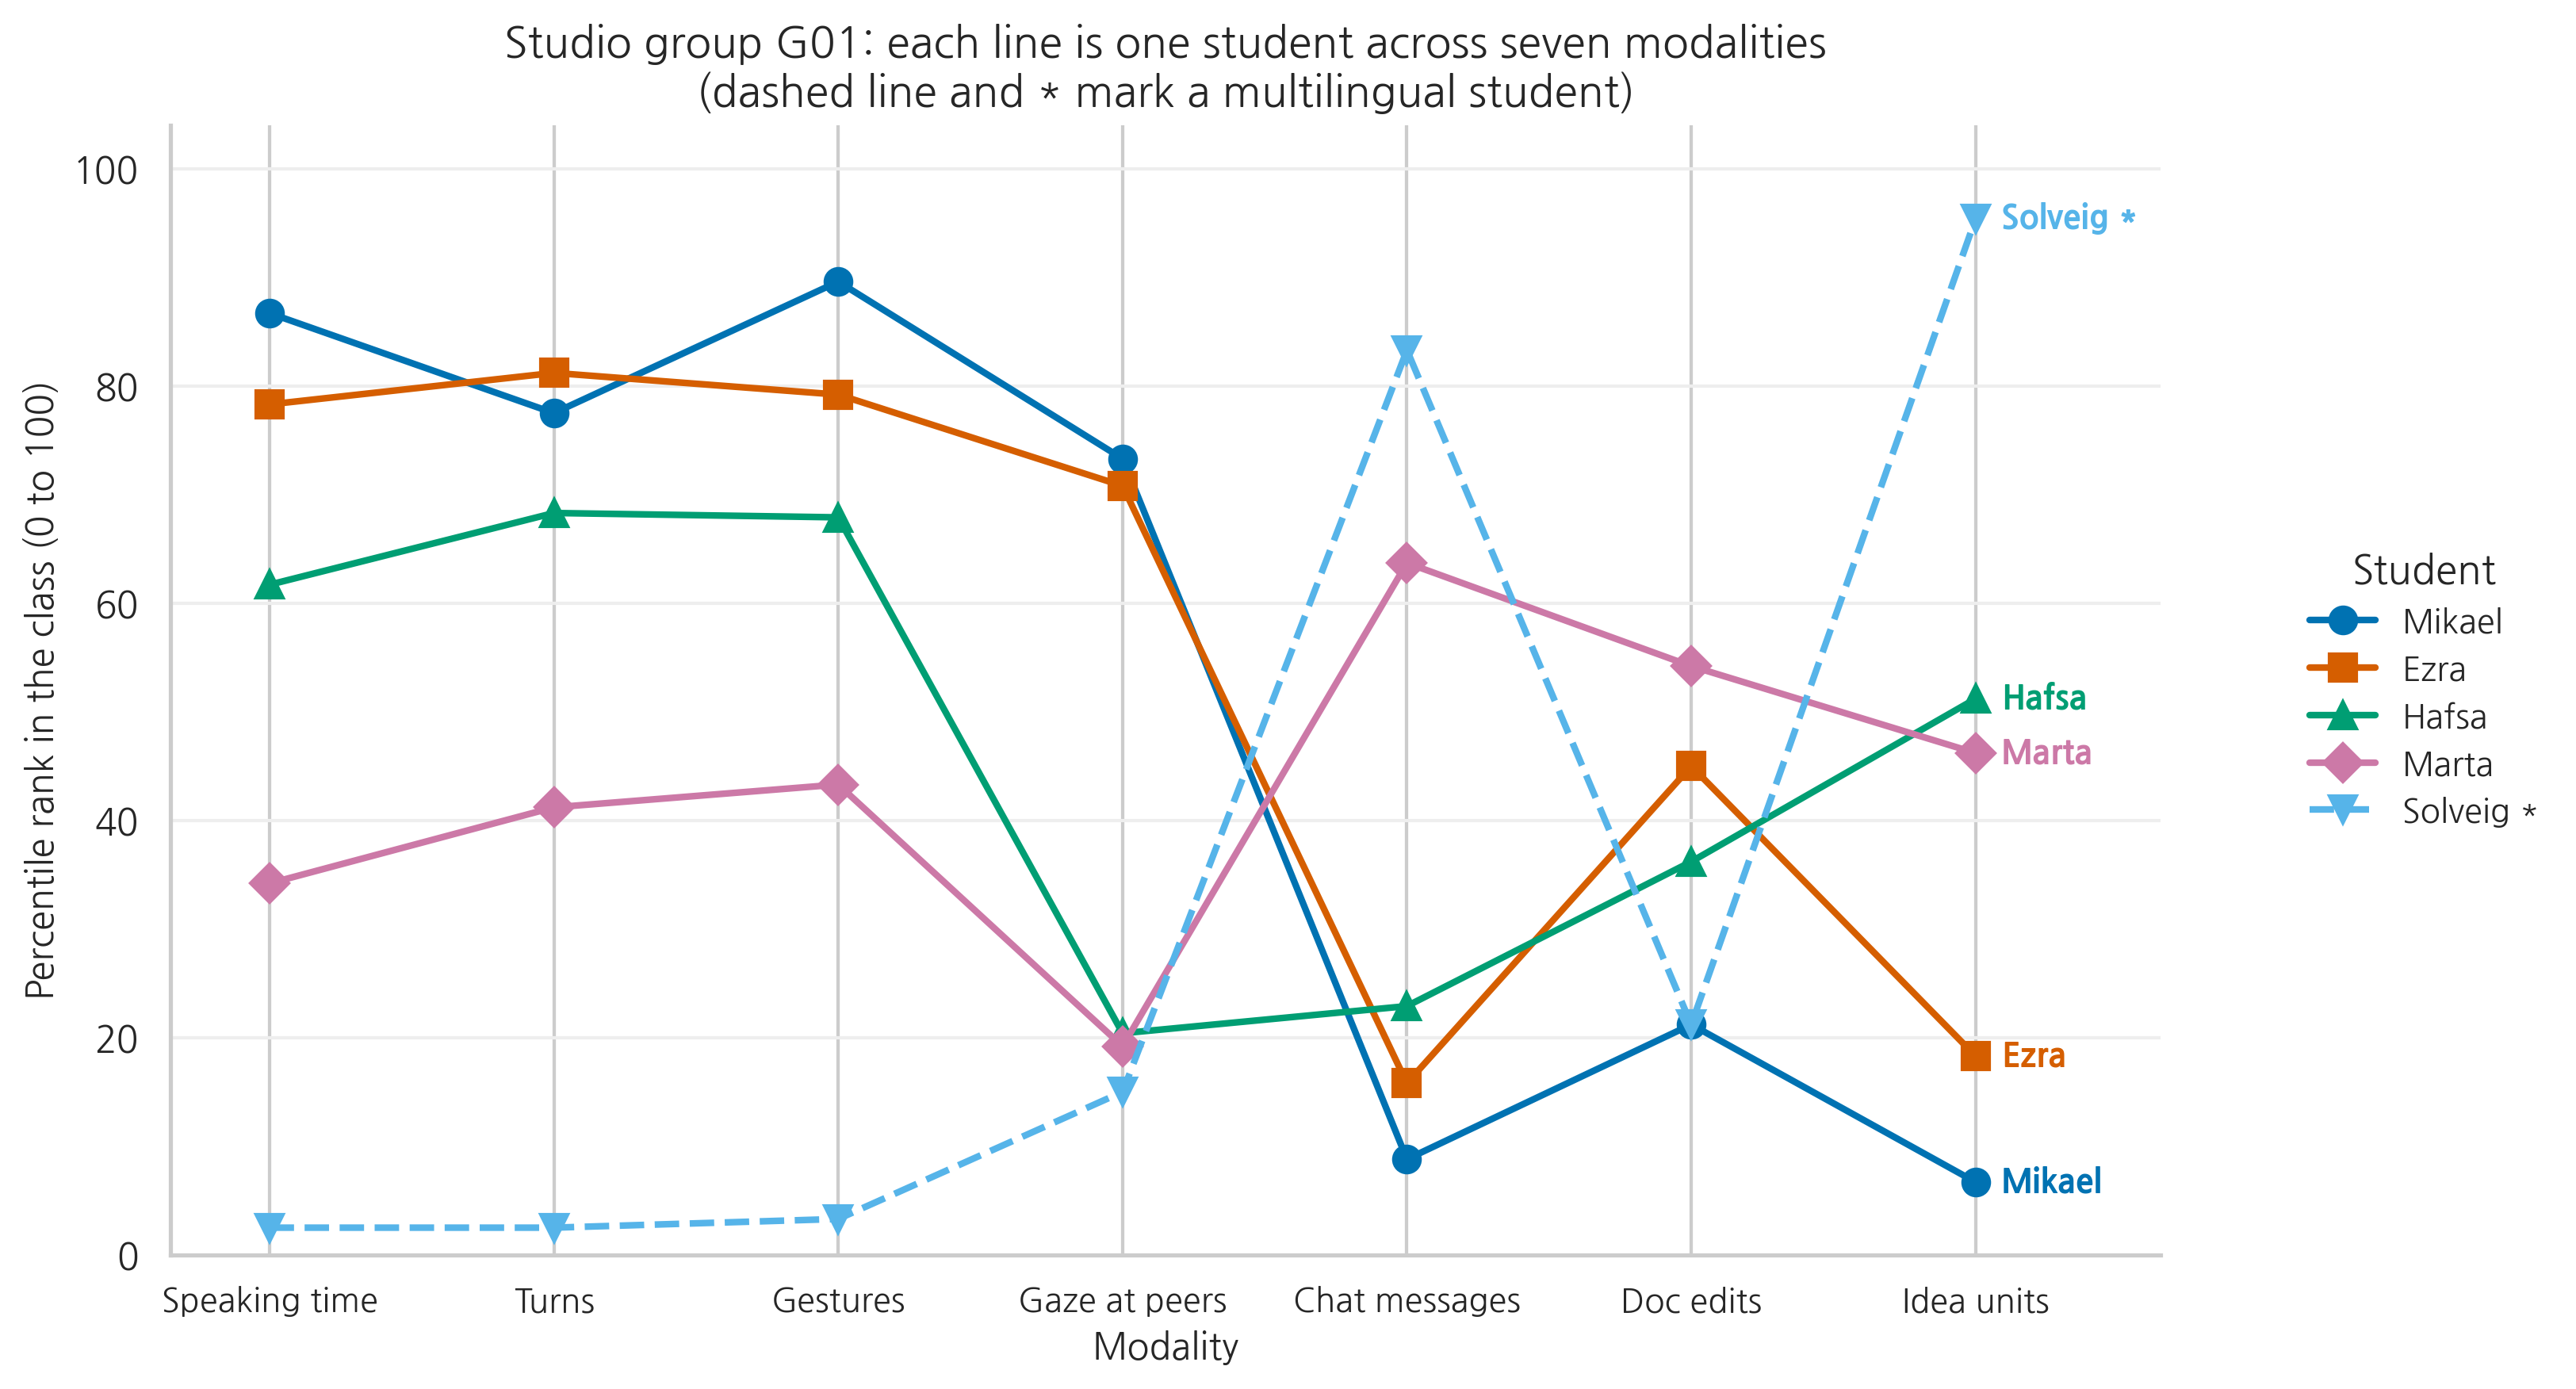

Mean artifact score for this group across 8 sessions: 5.50 (class mean 6.64)


In [8]:
def plot_parallel(group_id):
    sub = (profile[profile['group_id'] == group_id]
           .sort_values('pct_speaking_time_s', ascending=False)
           .reset_index(drop=True))
    x = np.arange(len(MODALITIES))

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, row in sub.iterrows():
        y = [row['pct_' + m] for m in MODALITIES]
        style = '--' if row['multilingual'] == 1 else '-'
        name = row['first_name'] + (' *' if row['multilingual'] == 1 else '')
        ax.plot(x, y, color=SERIES_COLORS[i % 5], marker=MARKERS[i % 5], linestyle=style,
                linewidth=2, markersize=8, label=name)
        ax.annotate(name, (x[-1] + 0.09, y[-1]), color=SERIES_COLORS[i % 5],
                    fontsize=10, va='center', fontweight='bold')

    for xv in x:
        ax.axvline(xv, color='#dddddd', linewidth=1, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[m] for m in MODALITIES], fontsize=10)
    ax.set_xlim(-0.35, len(MODALITIES) - 0.35)
    ax.set_ylim(0, 104)
    ax.set_ylabel('Percentile rank in the class (0 to 100)', fontsize=11)
    ax.set_xlabel('Modality', fontsize=11)
    ax.set_title(f'Studio group {group_id}: each line is one student across seven modalities\n'
                 f'(dashed line and * mark a multilingual student)', fontsize=13)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#eeeeee', linewidth=1)
    ax.set_axisbelow(True)
    ax.legend(title='Student', frameon=False, fontsize=10, loc='center left',
              bbox_to_anchor=(1.06, 0.5))
    plt.tight_layout()
    plt.show()


plot_parallel('G01')

print('Mean artifact score for this group across 8 sessions: '
      f"{artifacts.loc[artifacts['group_id'] == 'G01', 'artifact_score'].mean():.2f} "
      f"(class mean {artifacts['artifact_score'].mean():.2f})")

**💬 Interpret before moving on.** Find the line that starts near the bottom on the left and ends near the top on the right. Which modality is the "crossing point" where the group's ranking reorganizes itself? If you had to explain this figure to the five students in G01, what would you say about who was participating?

### ✏️ Your turn 2: look at a different group

Change `GROUP_ID` to any group from `G01` to `G24`. Groups worth a look: `G10`, `G13`, `G03`, `G20`.

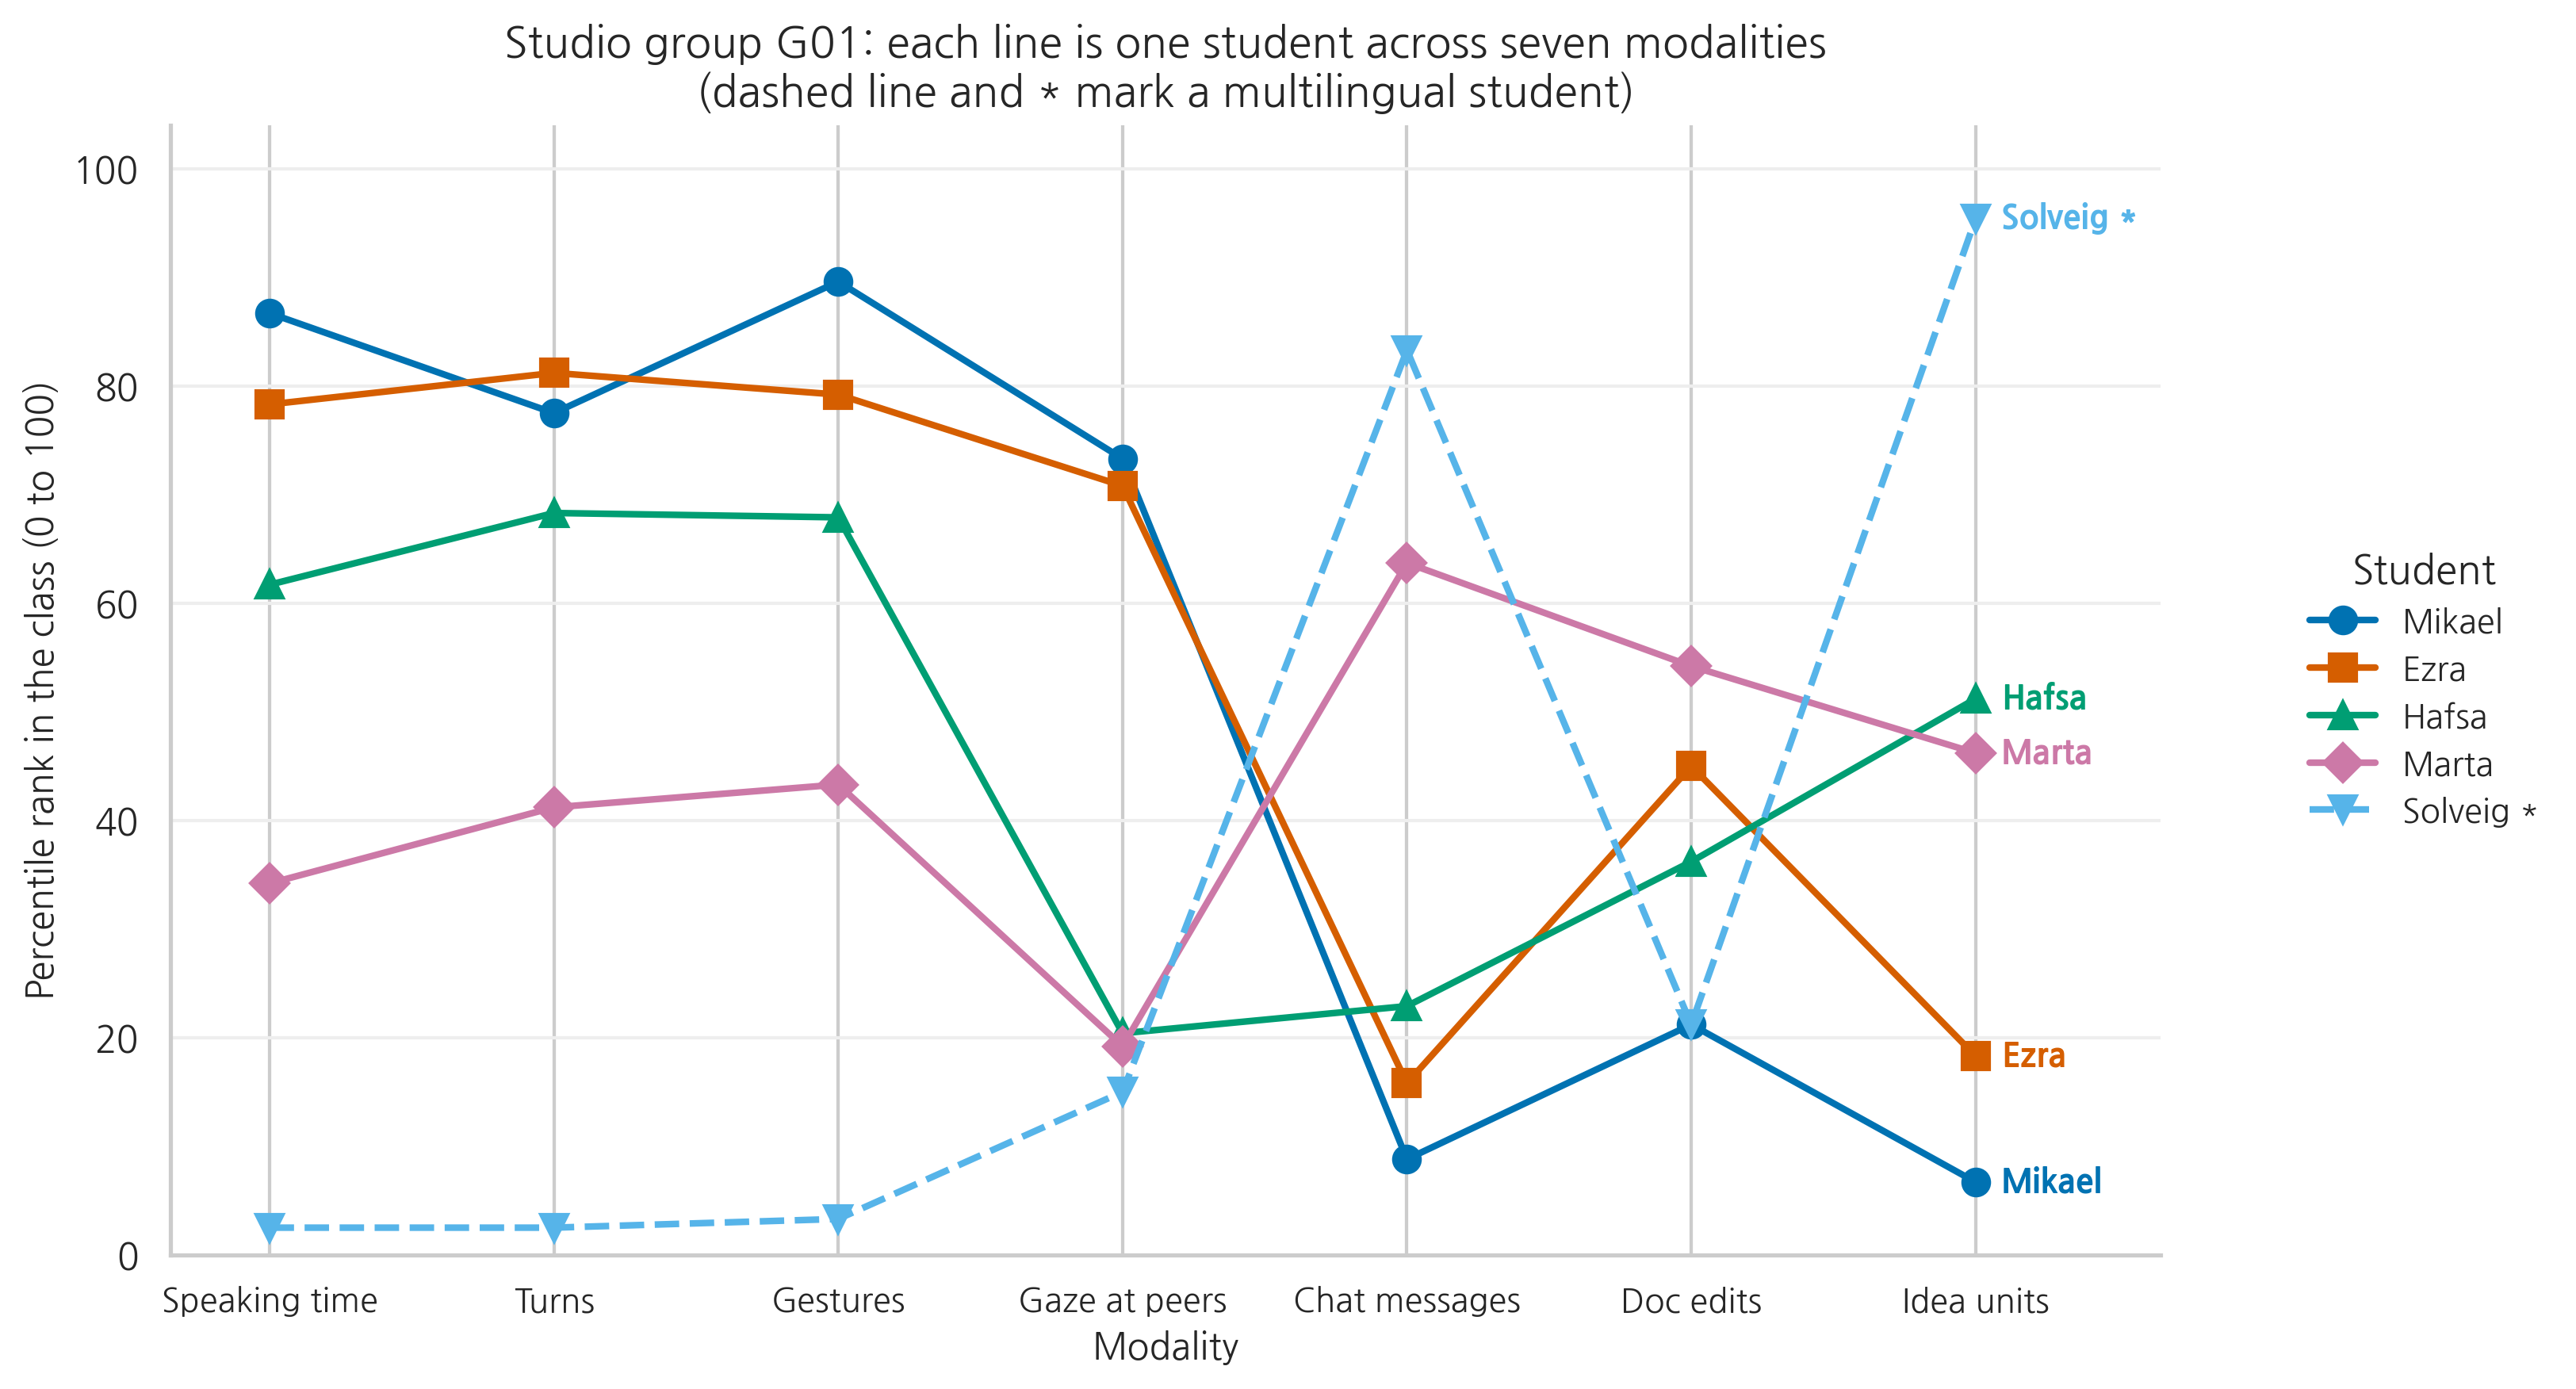

In [9]:
# TODO: change this group ID and re-run.
GROUP_ID = 'G01'

plot_parallel(GROUP_ID)

## 📊 4. Who flips? The whole class at once

Two students and one group are anecdotes. Now we ask the class-wide version: **how often does a student who is quiet on audio turn out to be a heavy contributor in the digital stream, and is it random who that happens to?**

The scatter below places every student by two percentiles: speaking time on the x axis, idea units contributed in chat on the y axis. If the two modalities told the same story, every point would sit near the dotted diagonal. The shaded rectangle in the upper left is the region that should not exist if speaking time were a fair proxy for participation: quiet on audio, top third on ideas.

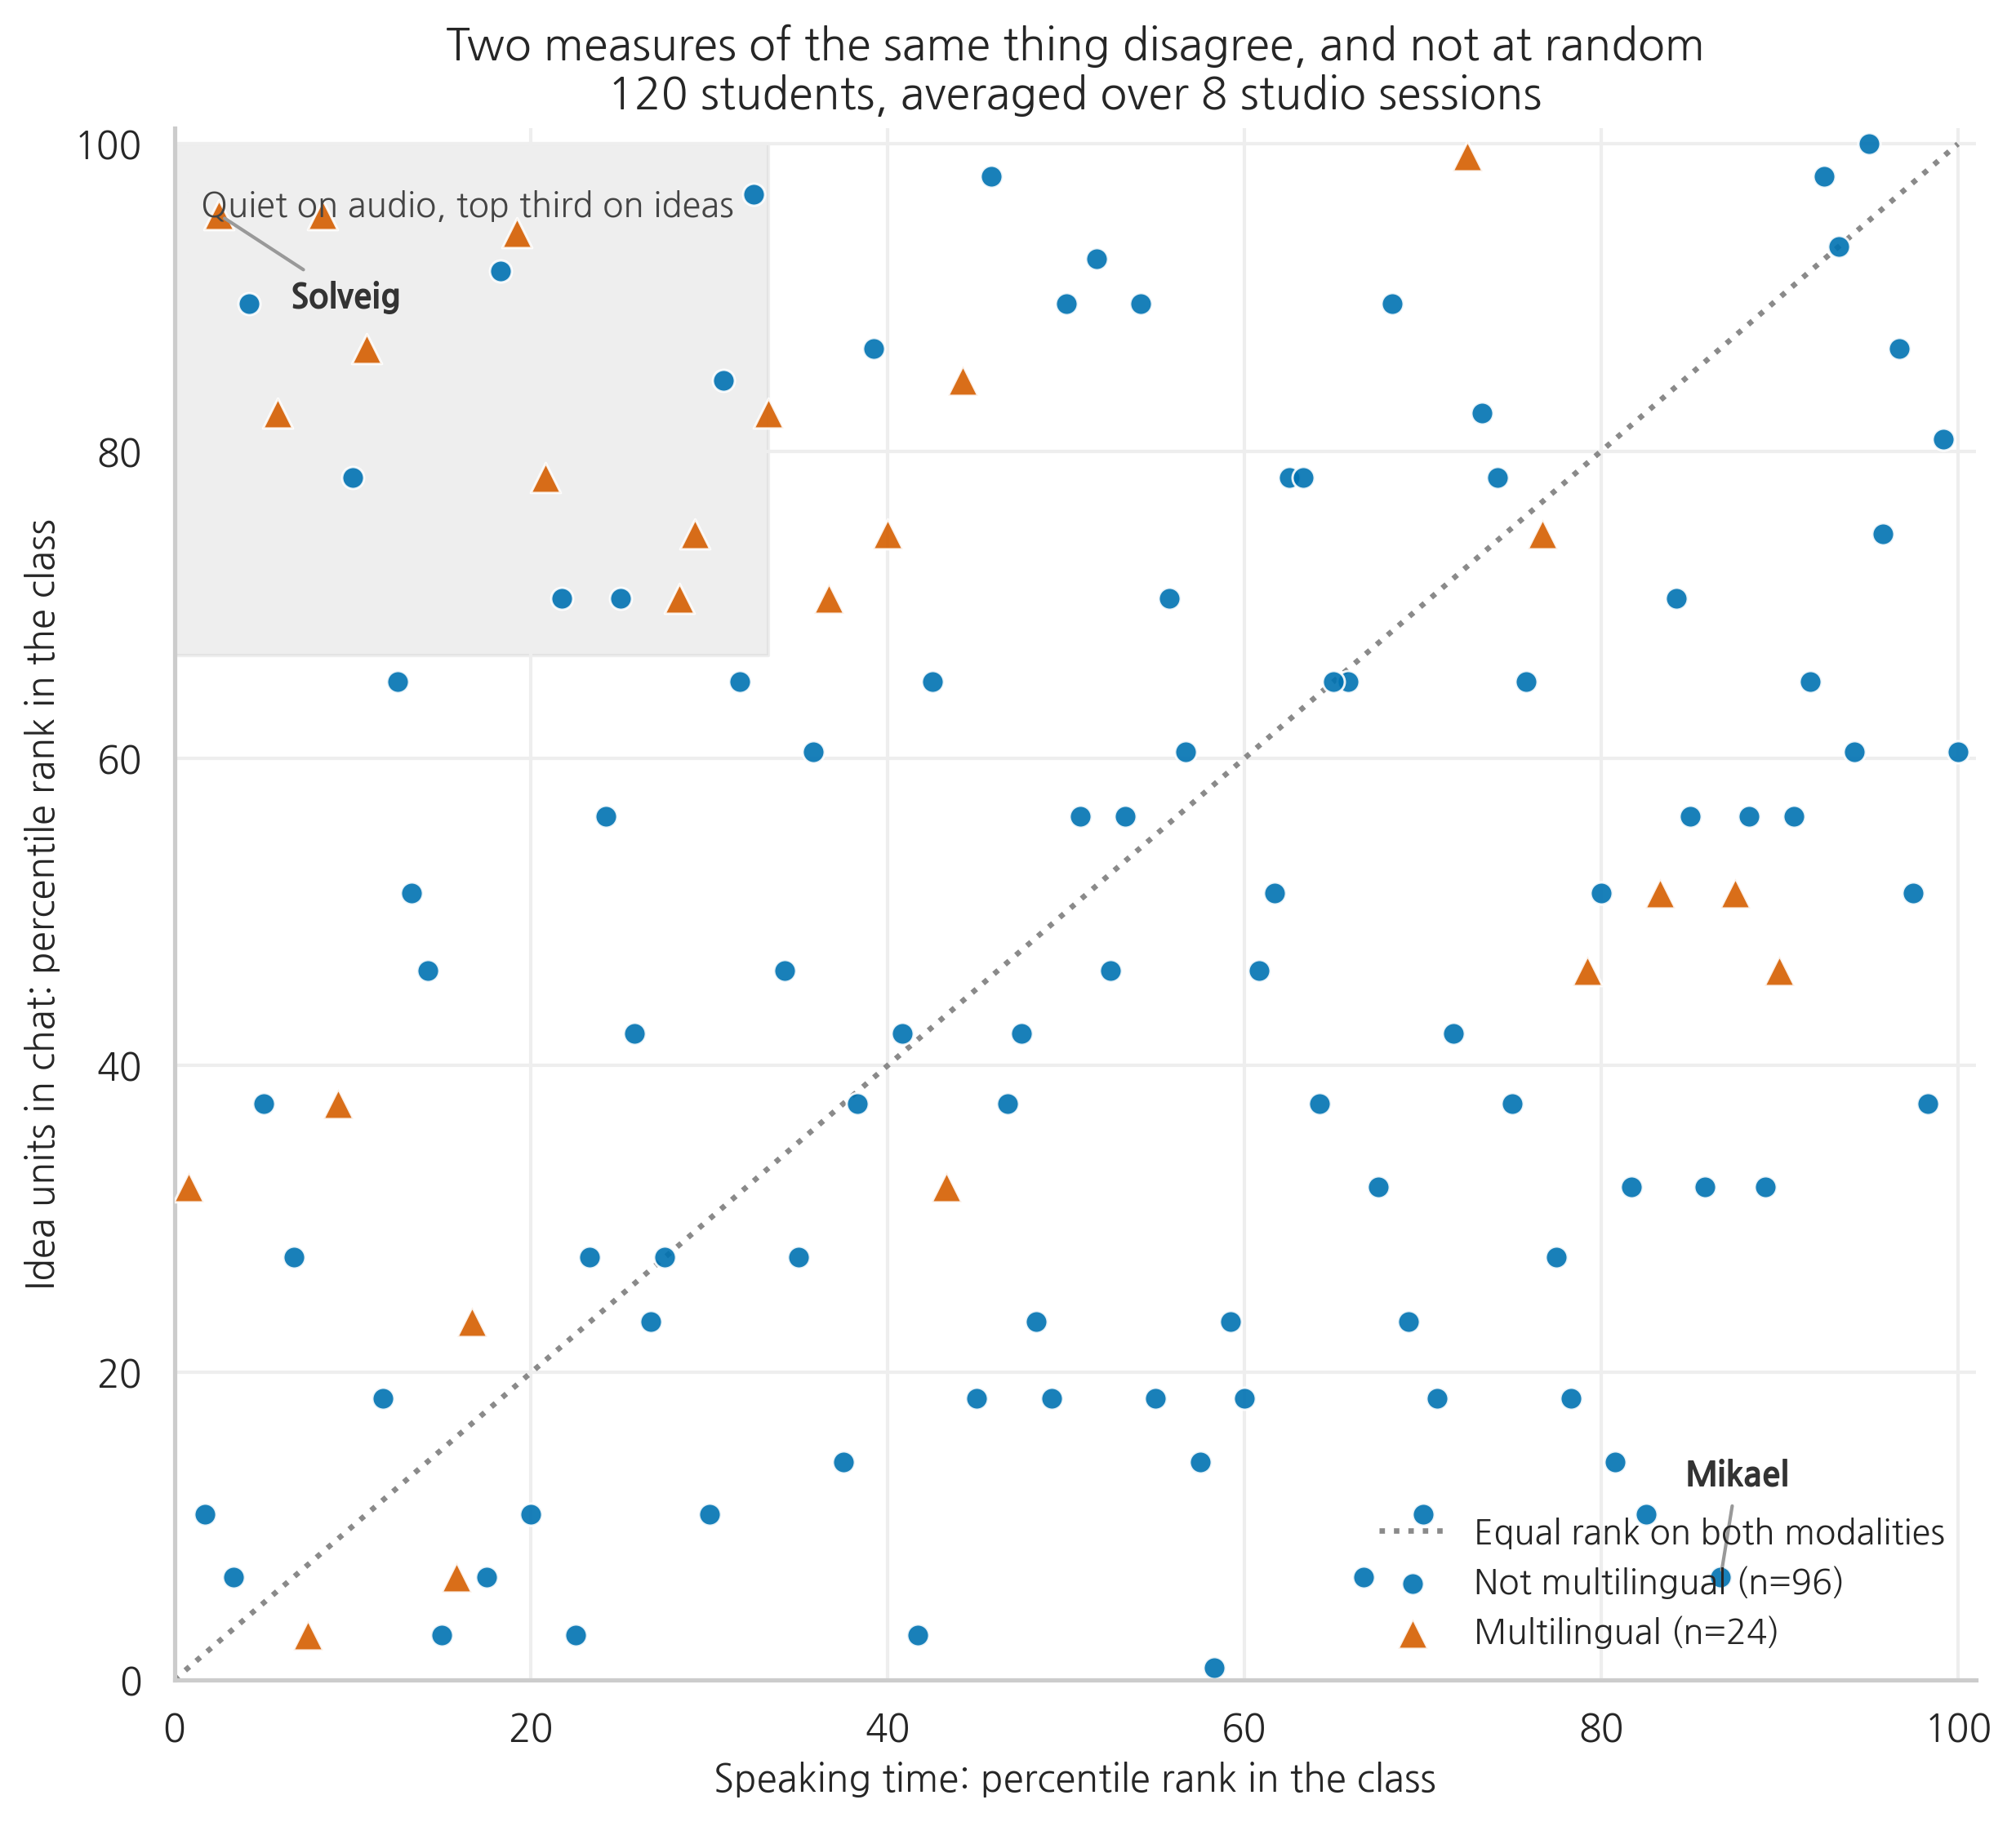

In [10]:
QUIET_CUT  = 33.3   # bottom third of speaking time
STRONG_CUT = 66.7   # top third of idea units

fig, ax = plt.subplots(figsize=(8.4, 7.6))

ax.fill_between([0, QUIET_CUT], STRONG_CUT, 100, color='#cfcfcf', alpha=0.35, zorder=0)
ax.plot([0, 100], [0, 100], color=GREY, linestyle=':', linewidth=1.6, zorder=1,
        label='Equal rank on both modalities')

for flag, color, marker, size, name in [
        (0, BLUE,   'o', 42, 'Not multilingual (n=96)'),
        (1, ORANGE, '^', 78, 'Multilingual (n=24)')]:
    s = profile[profile['multilingual'] == flag]
    ax.scatter(s['pct_speaking_time_s'], s['pct_idea_units_chat'],
               c=color, marker=marker, s=size, alpha=0.9,
               edgecolors='white', linewidths=0.7, zorder=3 if flag else 2, label=name)

for sid, dx, dy in [('S038', 4, -6), ('S076', -2, 6)]:
    r = profile.loc[profile['student_id'] == sid].iloc[0]
    ax.annotate(r['first_name'], (r['pct_speaking_time_s'], r['pct_idea_units_chat']),
                xytext=(r['pct_speaking_time_s'] + dx, r['pct_idea_units_chat'] + dy),
                fontsize=10, fontweight='bold', color='#333333',
                arrowprops=dict(arrowstyle='-', color='#999999', linewidth=1))

ax.text(1.5, 97, 'Quiet on audio, top third on ideas', fontsize=10, color='#444444', va='top')
ax.set_xlim(0, 101)
ax.set_ylim(0, 101)
ax.set_xlabel('Speaking time: percentile rank in the class', fontsize=11)
ax.set_ylabel('Idea units in chat: percentile rank in the class', fontsize=11)
ax.set_title('Two measures of the same thing disagree, and not at random\n'
             '120 students, averaged over 8 studio sessions', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

The picture is suggestive. Counting is better. The next cell puts numbers on the shaded rectangle: how many students live there, and who they are.

In [11]:
from math import comb, sqrt


def _wilson(k, n, z=1.96):
    """Wilson score interval for a proportion. Correct at small n, unlike k/n +- z*se."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def _binom_sf(k, n, p):
    """Exact P(X >= k) for X ~ Binomial(n, p). No scipy needed."""
    return sum(comb(n, j) * p ** j * (1 - p) ** (n - j) for j in range(k, n + 1))


quiet  = profile['pct_speaking_time_s'] <= QUIET_CUT
strong = profile['pct_idea_units_chat'] >= STRONG_CUT
flipped = profile[quiet & strong]

base_rate = profile['multilingual'].mean()
flip_rate = flipped['multilingual'].mean()

print(f'Students in the bottom third of speaking time      : {quiet.sum()}')
print(f'  ... of those, in the top third on idea units     : {len(flipped)}')
print()
print(f'Multilingual share of the class                    : {base_rate:.1%}  ({profile["multilingual"].sum()} of 120)')
print(f'Multilingual share of the "quiet but ideas" group   : {flip_rate:.1%}  ({flipped["multilingual"].sum()} of {len(flipped)})')
print(f'  Ratio                                            : {flip_rate / base_rate:.1f}x the base rate')
print()

# How much should you trust a proportion computed on 16 people? Say it, do not guess.
k, n_flip = int(flipped['multilingual'].sum()), len(flipped)
lo, hi = _wilson(k, n_flip)
p_exceed = _binom_sf(k, n_flip, base_rate)
print(f'That share rests on {n_flip} students, so put an interval on it.')
print(f'  95% interval for the multilingual share of this group : [{lo:.0%}, {hi:.0%}]')
print(f'  Chance of seeing {k} or more multilingual students among {n_flip} drawn')
print(f'  at the class base rate of {base_rate:.0%}                            : {p_exceed:.4f}')
print('  So the concentration is unlikely to be luck, and the SIZE of it is')
print('  known only to within about forty percentage points. Report both.')
print()
tbl = flipped[['student_id', 'first_name', 'last_name', 'multilingual',
               'pct_speaking_time_s', 'pct_idea_units_chat', 'pct_doc_edits']].copy()
tbl.columns = ['id', 'first', 'last', 'multilingual', 'speaking pct', 'idea pct', 'doc edit pct']
print(tbl.sort_values('speaking pct').to_string(index=False))

Students in the bottom third of speaking time      : 40
  ... of those, in the top third on idea units     : 16

Multilingual share of the class                    : 20.0%  (24 of 120)
Multilingual share of the "quiet but ideas" group   : 56.2%  (9 of 16)
  Ratio                                            : 2.8x the base rate

That share rests on 16 students, so put an interval on it.
  95% interval for the multilingual share of this group : [33%, 77%]
  Chance of seeing 9 or more multilingual students among 16 drawn
  at the class base rate of 20%                            : 0.0015
  So the concentration is unlikely to be luck, and the SIZE of it is
  known only to within about forty percentage points. Report both.

  id    first       last  multilingual  speaking pct  idea pct  doc edit pct
S038  Solveig     Petrov             1           2.5      95.4          21.2
S015     Yuki     Hassan             0           4.2      89.6          93.3
S023  Beatriz     Duarte             1   

**💬 Interpret before moving on.** Multilingual students are 20 percent of this class and 56 percent of this group of sixteen, an interval of roughly 33 to 77 percent. Two things follow, and they are different: the concentration is very unlikely to be chance (p = 0.0015), and its exact size is not pinned down by sixteen people. Write down both.

Then answer the question that matters: is this a story about these students, or a story about the microphone? Notice that only one of those two readings can be checked with the columns in front of you, and it is not the one about the students. Worsley, Martinez-Maldonado, and D'Angelo (2021) argue that MMLA work carries commitments to the people being sensed, not only to the sensors. Name one commitment this figure puts pressure on.

## 📊 5. Disaggregating: the same class, seven measures, two stories

An average over 120 students hides the thing we just found. **Disaggregation** means recomputing a measure separately for groups of students and comparing. It is not an optional extra step in learning analytics; it is how you find out whether your measure works the same way for everybody.

To compare across modalities with different units we use **Cohen's d**, a standardized difference. It answers: how many standard deviations apart are the two group means? A rough convention (Cohen's, and worth arguing with) reads 0.2 as small, 0.5 as medium, 0.8 as large. The sign tells you the direction: positive means multilingual students score higher on that modality.

In [12]:
def cohens_d(a, b):
    """Standardized mean difference (a minus b), pooled standard deviation.

    The pooled SD is weighted by degrees of freedom. That is the correct form
    whenever the groups differ in size, and here they differ by a factor of four.
    Averaging the two variances unweighted, which is a common shortcut, would put
    too much weight on the 24-student group.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd


def cohens_d_ci(a, b, z=1.96):
    """95% interval for Cohen's d, large-sample approximation.

    var(d) = (na + nb) / (na * nb) + d^2 / (2 * (na + nb)).
    With 24 students in one group these intervals are wide, and that is the point:
    a d reported without one invites a reader to treat 0.24 and 0.52 as different
    findings when this sample cannot tell them apart.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    d = cohens_d(a, b)
    se = np.sqrt((na + nb) / (na * nb) + d ** 2 / (2 * (na + nb)))
    return d - z * se, d + z * se


def modality_gaps(df, group_col):
    rows = []
    for m in MODALITIES:
        yes = df.loc[df[group_col] == 1, m]
        no  = df.loc[df[group_col] == 0, m]
        d = cohens_d(yes, no)
        lo, hi = cohens_d_ci(yes, no)
        rows.append({'modality'   : LABELS[m],
                     'stream'     : STREAM[m],
                     f'mean if {group_col}=1': round(yes.mean(), 2),
                     f'mean if {group_col}=0': round(no.mean(), 2),
                     "Cohen's d"  : round(d, 2),
                     '95% CI'     : f'[{lo:+.2f}, {hi:+.2f}]',
                     'CI excludes 0': 'yes' if lo * hi > 0 else 'no',
                     '_lo': lo, '_hi': hi})
    return pd.DataFrame(rows).sort_values("Cohen's d")


gaps = modality_gaps(profile, 'multilingual')
print(f"n multilingual = {int(profile['multilingual'].sum())}, "
      f"n not multilingual = {int((1 - profile['multilingual']).sum())}")
print('Seven modalities are compared here, so seven chances to see something.')
print('Read the pattern across all seven, not the largest single number.\n')
gaps.drop(columns=['_lo', '_hi'])

n multilingual = 24, n not multilingual = 96
Seven modalities are compared here, so seven chances to see something.
Read the pattern across all seven, not the largest single number.



,modality,stream,mean if multilingual=1,mean if multilingual=0,Cohen's d,95% CI,CI excludes 0
0,Speaking time,audio (mic array),455.44,653.83,-0.59,"[-1.04, -0.14]",yes
1,Turns,audio (mic array),30.34,43.20,-0.58,"[-1.03, -0.12]",yes
2,Gestures,video (pose model),11.49,13.95,-0.50,"[-0.96, -0.05]",yes
4,Chat messages,digital (workspace log),7.16,6.52,0.24,"[-0.21, +0.69]",no
5,Doc edits,digital (workspace log),4.62,3.67,0.41,"[-0.04, +0.86]",no
3,Gaze at peers,video (gaze model),39.81,38.26,0.42,"[-0.03, +0.87]",no
6,Idea units,digital (coded chat),2.86,2.27,0.52,"[+0.07, +0.97]",yes


The table is the evidence. The chart below is the argument: one bar per modality, ordered from the largest negative difference to the largest positive one, with zero marked and a 95% interval on every bar.

Read the intervals before you read the bars. With 24 students in one group, a single modality's effect size is a wide guess. What the figure supports is the **pattern**, that the sign flips when the sensor changes, not the precise size of any one bar.

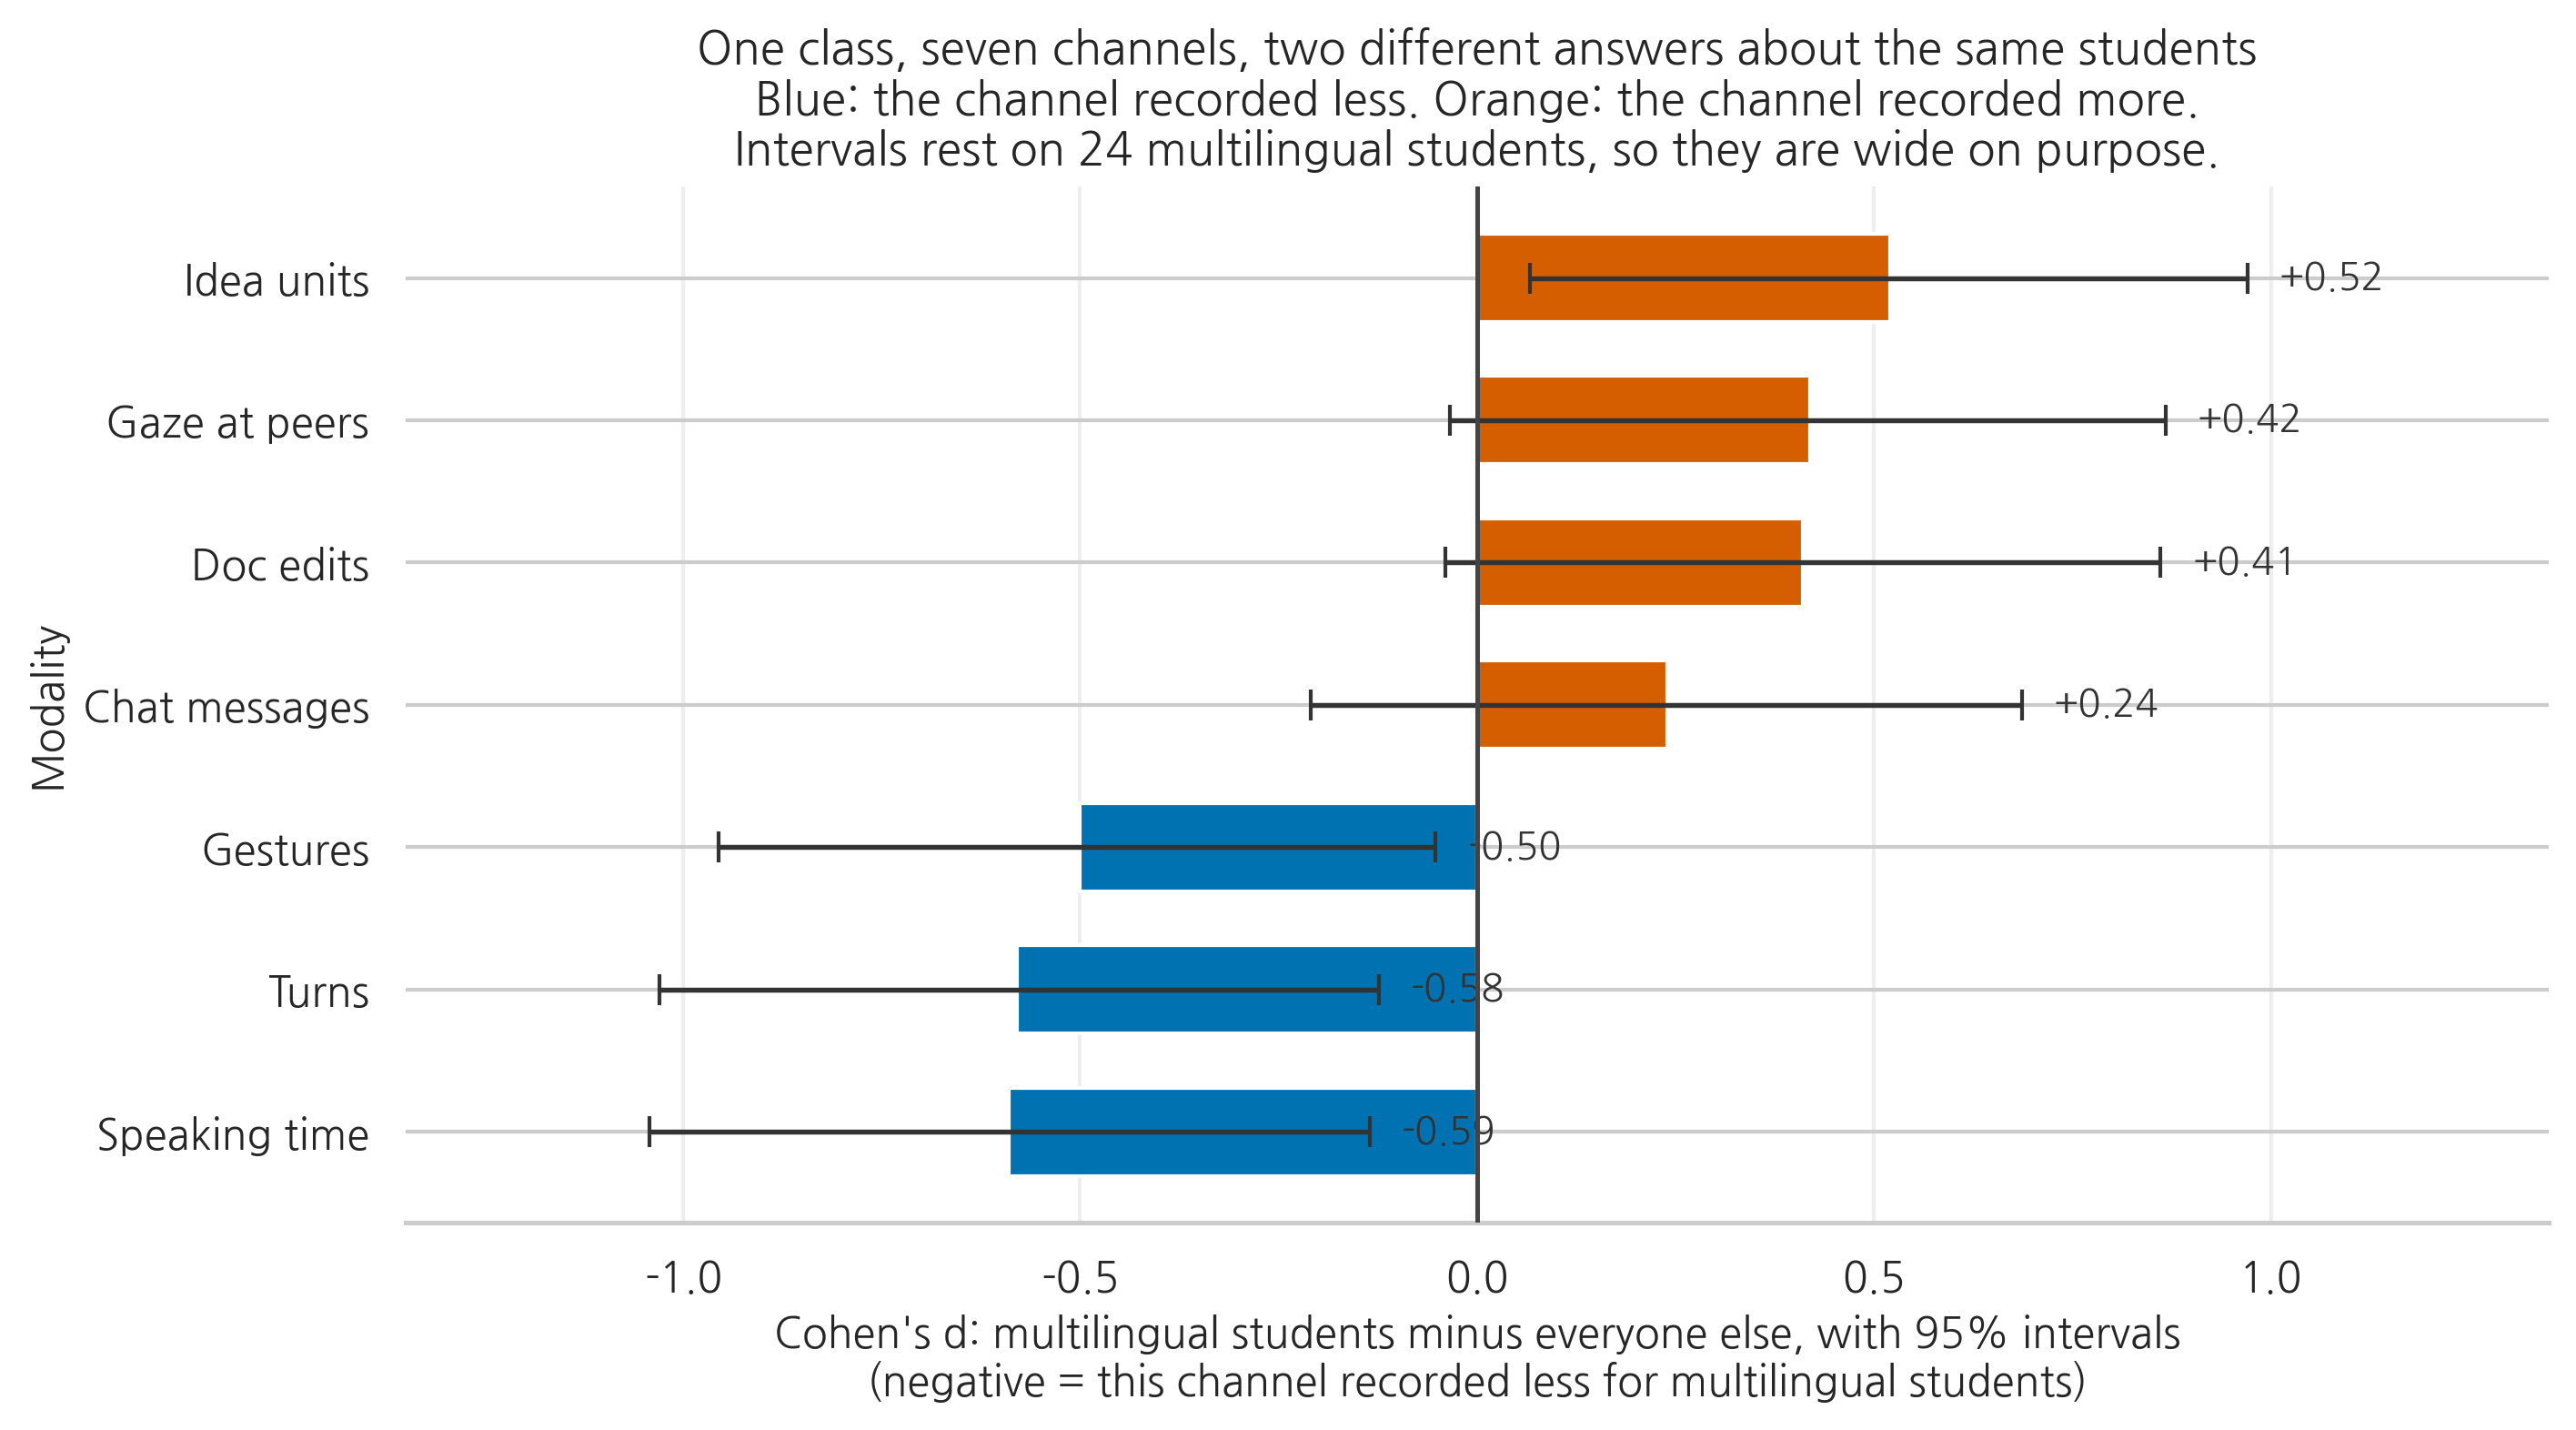

Same numbers, as a table:
     modality                  stream  Cohen's d         95% CI CI excludes 0
Speaking time       audio (mic array)      -0.59 [-1.04, -0.14]           yes
        Turns       audio (mic array)      -0.58 [-1.03, -0.12]           yes
     Gestures      video (pose model)      -0.50 [-0.96, -0.05]           yes
Chat messages digital (workspace log)       0.24 [-0.21, +0.69]            no
    Doc edits digital (workspace log)       0.41 [-0.04, +0.86]            no
Gaze at peers      video (gaze model)       0.42 [-0.03, +0.87]            no
   Idea units    digital (coded chat)       0.52 [+0.07, +0.97]           yes

Read that last column honestly. Three of the four positive differences have
an interval that touches zero. What this class can support is that the sign
depends on the sensor. What it cannot support is a precise claim about how
much more any one digital channel recorded.


In [13]:
g = gaps.sort_values("Cohen's d")
colors = [BLUE if v < 0 else ORANGE for v in g["Cohen's d"]]

err = np.vstack([g["Cohen's d"] - g['_lo'], g['_hi'] - g["Cohen's d"]])

fig, ax = plt.subplots(figsize=(9.6, 5.4))
bars = ax.barh(g['modality'], g["Cohen's d"], color=colors, height=0.62, zorder=3,
               xerr=err, error_kw=dict(ecolor='#333333', capsize=4, linewidth=1.3))
ax.axvline(0, color='#444444', linewidth=1.2, zorder=4)

for bar, v, hi in zip(bars, g["Cohen's d"], g['_hi']):
    ax.text(hi + 0.04, bar.get_y() + bar.get_height() / 2, f'{v:+.2f}',
            va='center', ha='left', fontsize=10, color='#333333')

ax.set_xlim(-1.35, 1.35)
ax.set_xlabel("Cohen's d: multilingual students minus everyone else, with 95% intervals\n"
              '(negative = this channel recorded less for multilingual students)',
              fontsize=11)
ax.set_ylabel('Modality', fontsize=11)
ax.set_title('One class, seven channels, two different answers about the same students\n'
             'Blue: the channel recorded less. Orange: the channel recorded more.\n'
             'Intervals rest on 24 multilingual students, so they are wide on purpose.',
             fontsize=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print('Same numbers, as a table:')
print(g[['modality', 'stream', "Cohen's d", '95% CI', 'CI excludes 0']].to_string(index=False))
print()
print('Read that last column honestly. Three of the four positive differences have')
print('an interval that touches zero. What this class can support is that the sign')
print('depends on the sensor. What it cannot support is a precise claim about how')
print('much more any one digital channel recorded.')

**💬 Interpret before moving on.** The audio and video streams point one way, the digital streams point the other, and both are "the data". Lee, Sung, Celedón-Pattichis, and Pattichis (2026) make exactly this argument about linguistic diversity in collaborative work.

Write two sentences: first, what a single-modality report would have concluded about multilingual students in this class; second, what you would say instead, and what evidence you would show to back it.

Then a third sentence, which is the harder one. Given the intervals, which specific claim from this figure would you be willing to put in writing to a department chair, and which would you have to soften? The claim that survives is not "multilingual students contribute more in chat." It is that **a class list ordered by speaking time is a different class list from one ordered by contribution to the shared document, and the two disagree most about the same twenty-four people.**

### ✏️ Your turn 3: disaggregate by something else

`multilingual` is not the only 0/1 column on the roster. Change `GROUP_COLUMN` below to `'first_gen'` and re-run. The function is the same; only the grouping changes.

Watch what happens to the size of the effects. Not every disaggregation finds something, and reporting a null result honestly is part of the job.

In [14]:
# TODO: change to 'first_gen' (or back to 'multilingual') and re-run.
GROUP_COLUMN = 'multilingual'

D_COL = "Cohen's d"

result = modality_gaps(profile, GROUP_COLUMN)
print(f'Disaggregating by: {GROUP_COLUMN}   '
      f'(n with {GROUP_COLUMN}=1: {int(profile[GROUP_COLUMN].sum())} of {len(profile)})\n')
print(result.to_string(index=False))
print()
biggest = result.iloc[result[D_COL].abs().argmax()]
print('Largest single-modality gap: ' + biggest['modality'] + f' (d = {biggest[D_COL]:+.2f})')

Disaggregating by: multilingual   (n with multilingual=1: 24 of 120)

     modality                  stream  mean if multilingual=1  mean if multilingual=0  Cohen's d         95% CI CI excludes 0       _lo       _hi
Speaking time       audio (mic array)                  455.44                  653.83      -0.59 [-1.04, -0.14]           yes -1.042131 -0.135202
        Turns       audio (mic array)                   30.34                   43.20      -0.58 [-1.03, -0.12]           yes -1.030256 -0.123806
     Gestures      video (pose model)                   11.49                   13.95      -0.50 [-0.96, -0.05]           yes -0.955651 -0.051999
Chat messages digital (workspace log)                    7.16                    6.52       0.24 [-0.21, +0.69]            no -0.209992  0.686652
    Doc edits digital (workspace log)                    4.62                    3.67       0.41 [-0.04, +0.86]            no -0.039495  0.861138
Gaze at peers      video (gaze model)                 

## 📊 6. Measuring balance: the Gini coefficient, carefully

So far we have compared students to each other. Now we change the unit of analysis to **the group in one session**, and ask a different question: was the floor shared, or did one person hold it?

The Gini coefficient is the standard tool for this, borrowed from economics where it describes income inequality. We introduce it properly here because it comes back in Week 9.

**The intuition.** Line the five group members up from least talk time to most, and walk along the line adding up the share of talk you have accumulated. In a perfectly balanced group, after 2 of 5 people you have accumulated 40 percent of the talk, after 4 of 5 you have 80 percent, and the walk is a straight diagonal line. In a dominated group the walk stays flat and then leaps at the end. The **Lorenz curve** is that walk. The **Gini coefficient** is twice the area between the diagonal and the curve.

**The scale.**
- Gini = 0 means everyone spoke exactly the same amount.
- Higher Gini means more concentrated talk.
- Gini = 1 is the theoretical maximum (one person holds every second of the floor), but it is only reachable with infinitely many people. **In a group of five the maximum possible Gini is 0.8.** That ceiling matters for interpretation, and it is a detail most dashboards get wrong.

**Two preconditions, before you point this at anything.**

1. **Gini needs a ratio scale with a real zero.** "Zero seconds of talk" means no talk. "Zero percent gaze at peers" would mean never looking at anybody, and no student in this file is near it: `gaze_peer_pct` runs from 17 to 61. Computing a Gini on a bounded percentage that never approaches zero returns a small number that means "these values are all similar", not "this was shared fairly". You will meet exactly this trap in Your turn 4.
2. **Gini on five people is a noisy number.** We use the population form, dividing by `n`, which is the form that makes 0.8 the ceiling for a group of five. Some software uses a sample-corrected form multiplying by `n / (n - 1)`, which would put the same session at a different value. Two consequences: say which form you used, and never compare a Gini computed on groups of five with one computed on groups of eight, because the ceilings differ.

**The formula** we use, for values sorted ascending as `x[1] ... x[n]`:

G = ( 2 * sum(i * x[i]) ) / ( n * sum(x) ) - (n + 1) / n

Run the next cell to compute it on three invented groups, so you can see what a number like 0.45 feels like before you meet 192 of them.

In [15]:
def gini(values):
    """Gini coefficient of a list of non-negative values. 0 = perfectly equal.

    For n people the maximum possible value is (n - 1) / n, so 0.8 for a group of 5.
    """
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return (2.0 * np.sum(index * x)) / (n * x.sum()) - (n + 1.0) / n


toy_groups = {
    'Perfectly even (5 x 900 s)'   : [900, 900, 900, 900, 900],
    'Mild imbalance'               : [1500, 1100, 900, 650, 350],
    'One student holds the floor'  : [3400, 500, 300, 200, 100],
    'Extreme: only one speaks'     : [4500, 0, 0, 0, 0],
}

for name, secs in toy_groups.items():
    shares = np.sort(np.array(secs) / np.sum(secs) * 100)[::-1]
    share_txt = ' / '.join(f'{s:.0f}%' for s in shares)
    print(f'{name:30s} Gini = {gini(secs):.3f}   talk shares: {share_txt}')

print()
print('Maximum possible Gini for a group of 5 :', round(gini([1, 0, 0, 0, 0]), 3))
print('Maximum possible Gini for a group of 25:', round(gini([1] + [0] * 24), 3))

Perfectly even (5 x 900 s)     Gini = 0.000   talk shares: 20% / 20% / 20% / 20% / 20%
Mild imbalance                 Gini = 0.244   talk shares: 33% / 24% / 20% / 14% / 8%
One student holds the floor    Gini = 0.613   talk shares: 76% / 11% / 7% / 4% / 2%
Extreme: only one speaks       Gini = 0.800   talk shares: 100% / 0% / 0% / 0% / 0%

Maximum possible Gini for a group of 5 : 0.8
Maximum possible Gini for a group of 25: 0.96


Now the same four groups as Lorenz curves. Read the gap between each curve and the diagonal: that gap **is** the Gini.

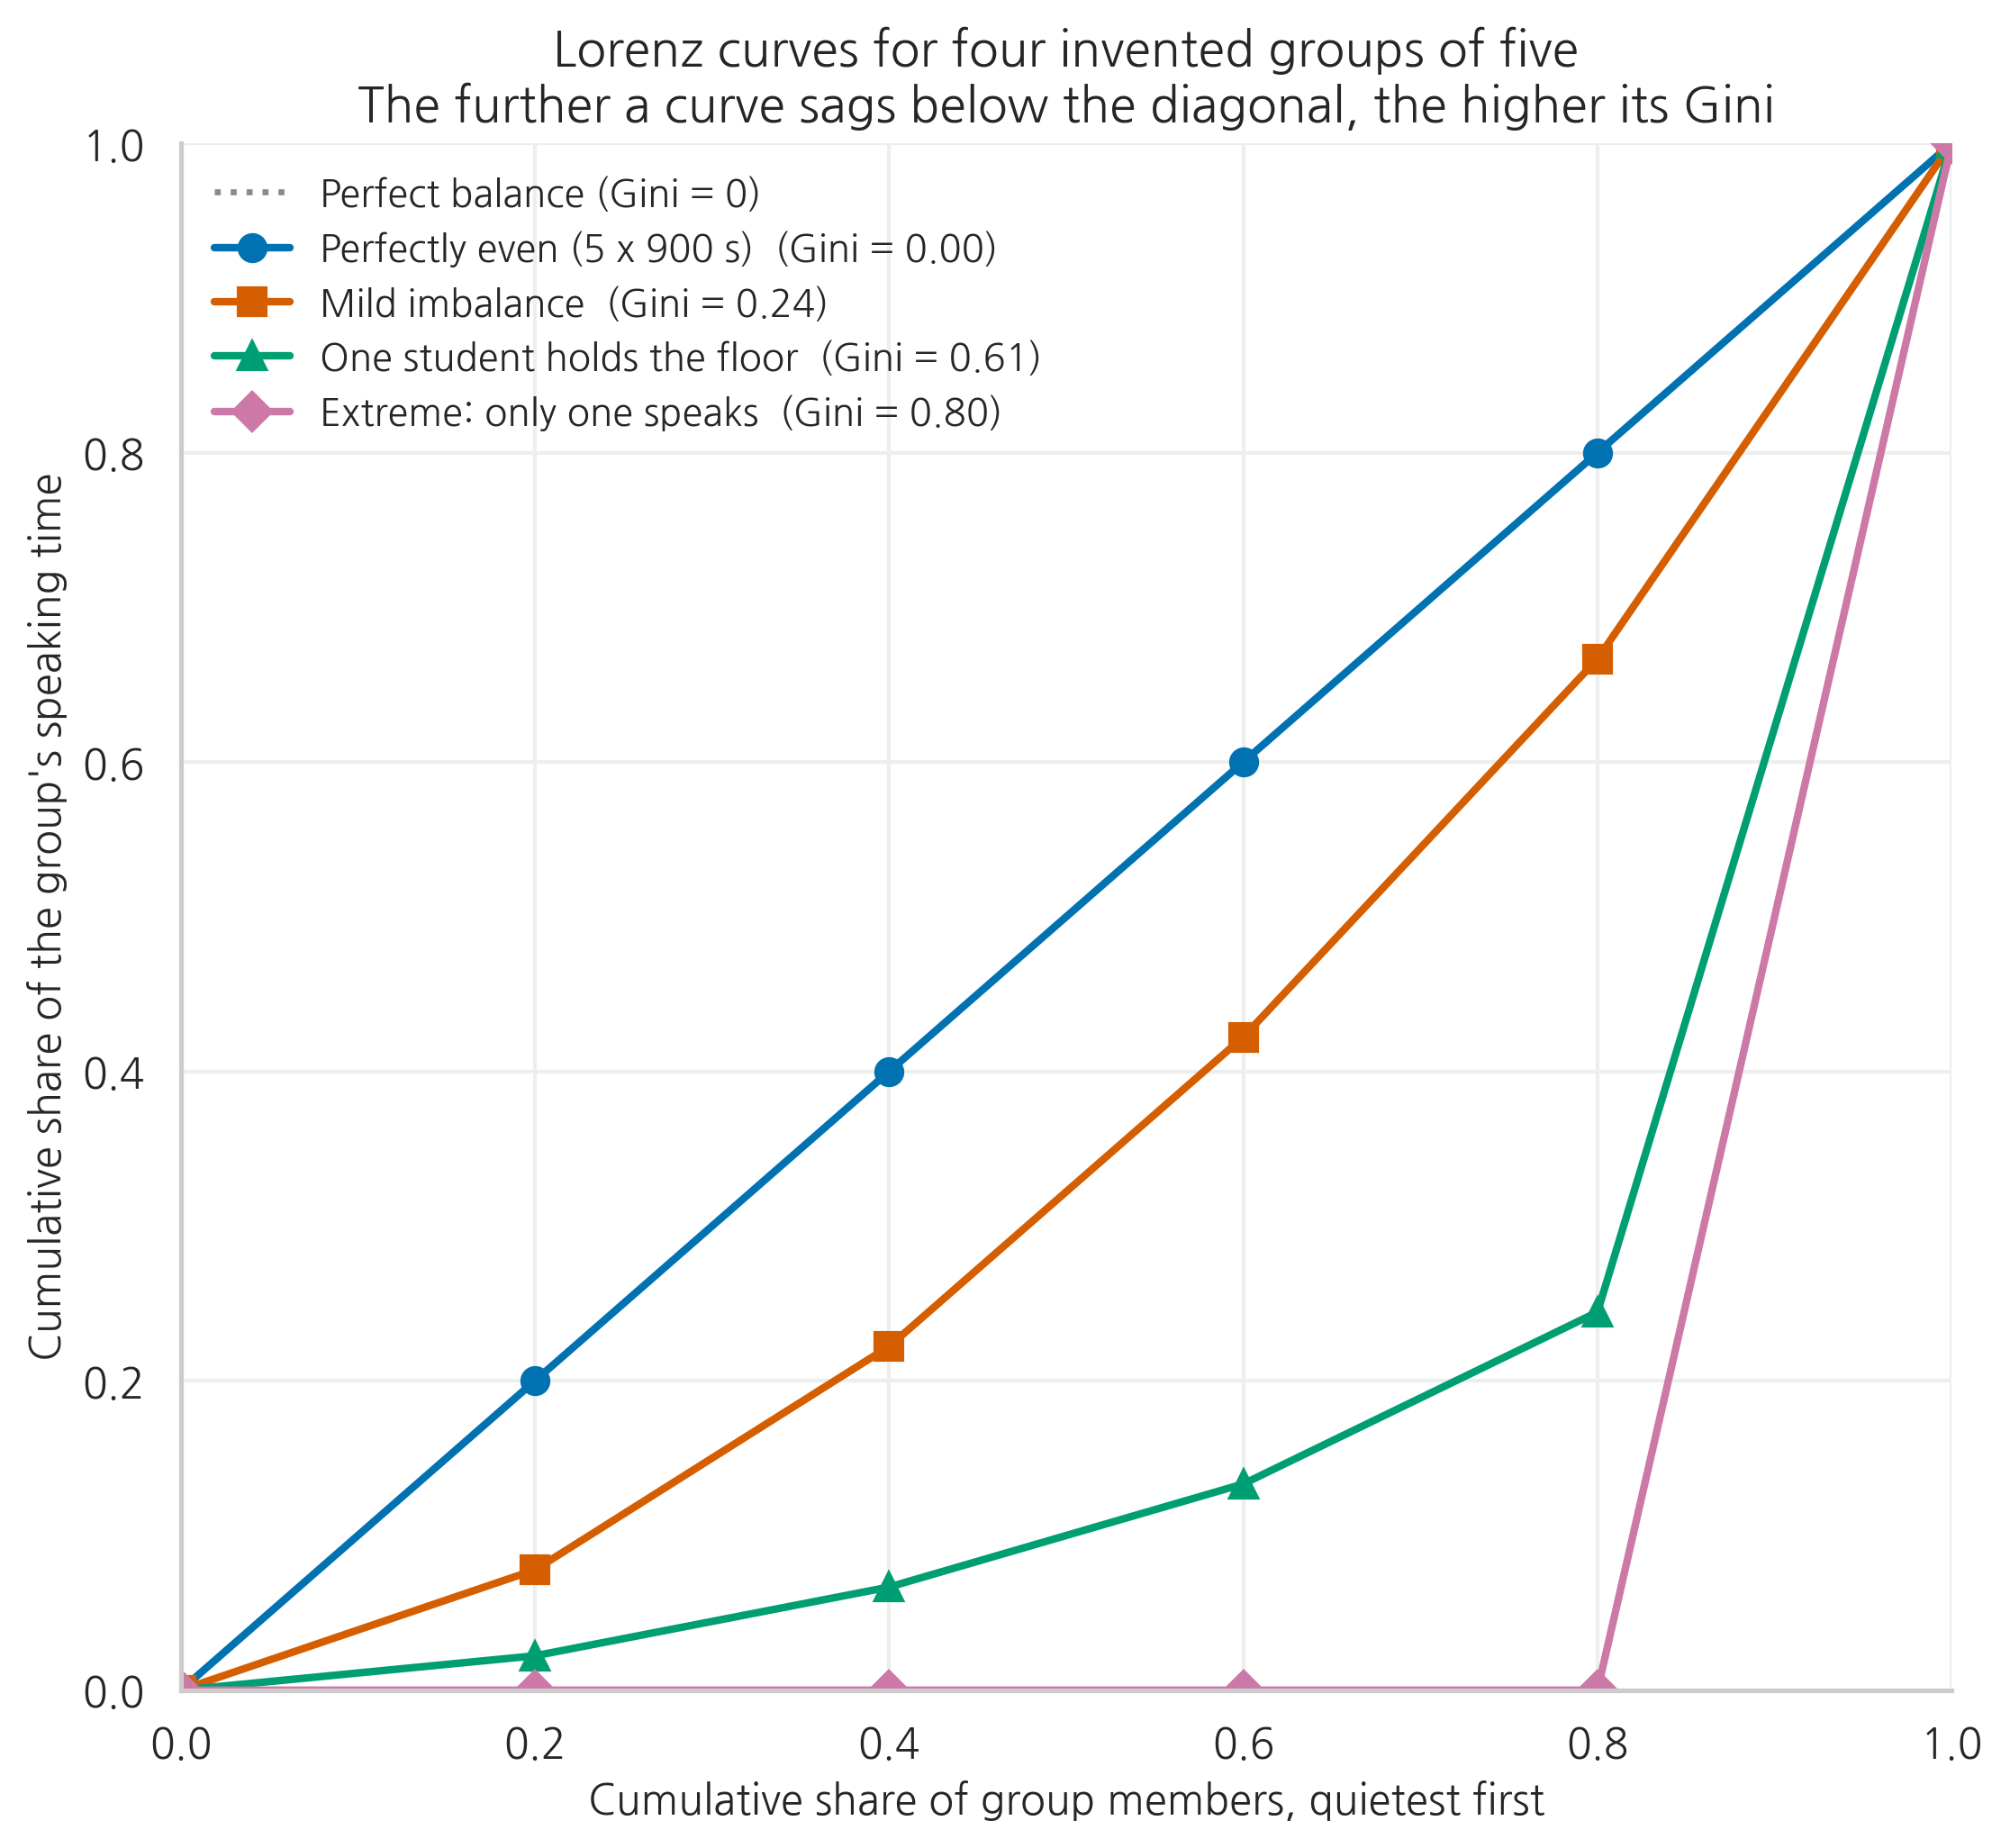

In [16]:
def lorenz_points(values):
    """Return (x, y) points of the Lorenz curve: cumulative share of people vs of talk."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    cum = np.cumsum(x)
    cum_share = np.insert(cum / cum[-1], 0, 0.0) if cum[-1] > 0 else np.zeros(n + 1)
    people_share = np.linspace(0, 1, n + 1)
    return people_share, cum_share


fig, ax = plt.subplots(figsize=(7.6, 7.0))
ax.plot([0, 1], [0, 1], color=GREY, linestyle=':', linewidth=1.6,
        label='Perfect balance (Gini = 0)')

for i, (name, secs) in enumerate(toy_groups.items()):
    px, py = lorenz_points(secs)
    ax.plot(px, py, color=SERIES_COLORS[i % 5], marker=MARKERS[i % 5], linewidth=2,
            markersize=7, label=f'{name}  (Gini = {gini(secs):.2f})')

ax.set_xlabel('Cumulative share of group members, quietest first', fontsize=11)
ax.set_ylabel('Cumulative share of the group\'s speaking time', fontsize=11)
ax.set_title('Lorenz curves for four invented groups of five\n'
             'The further a curve sags below the diagonal, the higher its Gini', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

**💬 Interpret before moving on.** Two groups can share a Gini of 0.45 and look nothing alike: one has a single dominant speaker and four equal peers, the other has two talkers and three silent members. Gini is a summary of the *shape* of the distribution and says nothing about *who* is quiet. Write one sentence naming a decision you would not make on the basis of a Gini value alone.

### 6.1 Gini in the real sessions

Now we compute the same number for all 192 group sessions (24 groups x 8 sessions), then look at the distribution and at the two most extreme sessions in the dataset.

In [17]:
gini_by_session = (mmla.groupby(['group_id', 'session_id'])['speaking_time_s']
                   .apply(gini)
                   .reset_index(name='talk_gini'))

sessions = gini_by_session.merge(artifacts, on=['group_id', 'session_id'])

print('Speaking-time Gini across', len(sessions), 'group sessions')
print(sessions['talk_gini'].describe().round(3).to_string())
print()
print('Most balanced sessions:')
print(sessions.nsmallest(3, 'talk_gini').round(3).to_string(index=False))
print()
print('Most dominated sessions:')
print(sessions.nlargest(3, 'talk_gini').round(3).to_string(index=False))

Speaking-time Gini across 192 group sessions
count    192.000
mean       0.348
std        0.127
min        0.070
25%        0.251
50%        0.330
75%        0.427
max        0.681

Most balanced sessions:
group_id session_id  talk_gini  artifact_score
     G21   studio_2      0.070             5.5
     G22   studio_1      0.088             6.8
     G21   studio_4      0.100             6.9

Most dominated sessions:
group_id session_id  talk_gini  artifact_score
     G04   studio_5      0.681             5.3
     G01   studio_1      0.660             3.8
     G17   studio_4      0.653             6.4


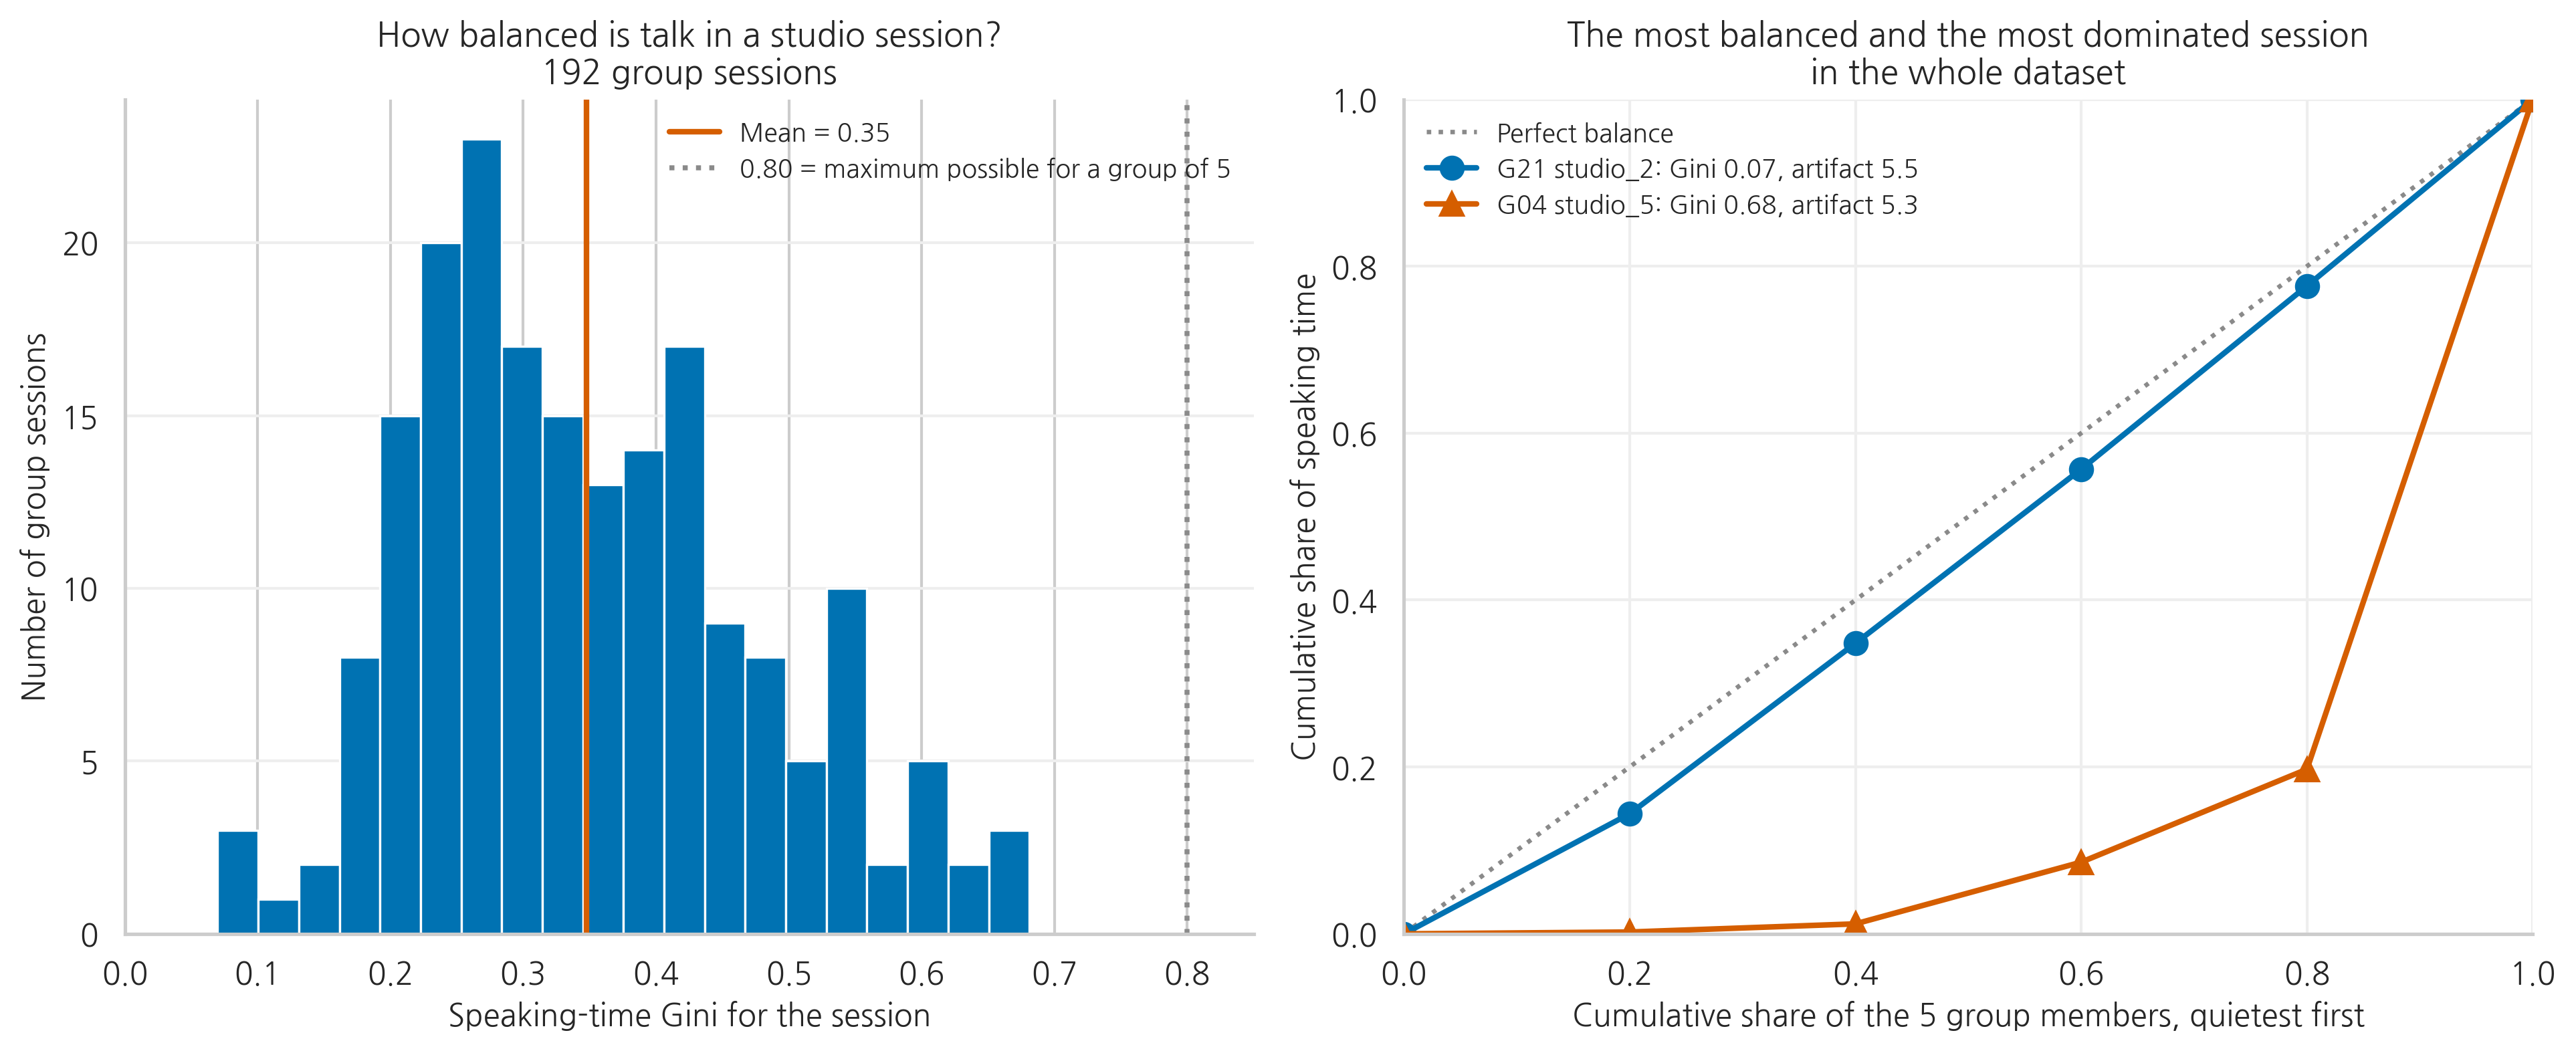

G21 studio_2  Gini 0.07  ->  Thandiwe (S085) 22%, Sofia (S094) 22%, Sofia (S111) 21%, Hugo (S098) 20%, Adaeze (S115) 14%
G04 studio_5  Gini 0.68  ->  Nikhil (S090) 80%, Hana (S002) 11%, Anika (S050) 7%, Felix (S087) 1%, Maya (S102) 0%


In [18]:
most_even = sessions.loc[sessions['talk_gini'].idxmin()]
most_dom  = sessions.loc[sessions['talk_gini'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

ax = axes[0]
ax.hist(sessions['talk_gini'], bins=20, color=BLUE, edgecolor='white', linewidth=0.8)
ax.axvline(sessions['talk_gini'].mean(), color=ORANGE, linewidth=2,
           label=f"Mean = {sessions['talk_gini'].mean():.2f}")
ax.axvline(0.8, color=GREY, linestyle=':', linewidth=1.8,
           label='0.80 = maximum possible for a group of 5')
ax.set_xlabel('Speaking-time Gini for the session', fontsize=11)
ax.set_ylabel('Number of group sessions', fontsize=11)
ax.set_title('How balanced is talk in a studio session?\n192 group sessions', fontsize=12)
ax.set_xlim(0, 0.85)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc='upper right')

ax = axes[1]
ax.plot([0, 1], [0, 1], color=GREY, linestyle=':', linewidth=1.6, label='Perfect balance')
for row, color, marker in [(most_even, BLUE, 'o'), (most_dom, ORANGE, '^')]:
    secs = mmla[(mmla['group_id'] == row['group_id']) &
                (mmla['session_id'] == row['session_id'])]['speaking_time_s']
    px, py = lorenz_points(secs)
    ax.plot(px, py, color=color, marker=marker, linewidth=2, markersize=8,
            label=f"{row['group_id']} {row['session_id']}: Gini {row['talk_gini']:.2f}, "
                  f"artifact {row['artifact_score']:.1f}")
ax.set_xlabel('Cumulative share of the 5 group members, quietest first', fontsize=11)
ax.set_ylabel('Cumulative share of speaking time', fontsize=11)
ax.set_title('The most balanced and the most dominated session\nin the whole dataset', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

for row in [most_even, most_dom]:
    secs = (mmla[(mmla['group_id'] == row['group_id']) &
                 (mmla['session_id'] == row['session_id'])]
            .merge(students[['student_id', 'first_name']], on='student_id')
            .sort_values('speaking_time_s', ascending=False))
    share = (secs['speaking_time_s'] / secs['speaking_time_s'].sum() * 100).round(0).astype(int)
    print(f"{row['group_id']} {row['session_id']}  Gini {row['talk_gini']:.2f}  ->  " +
          ', '.join(f'{n} ({i}) {s}%'
                    for n, i, s in zip(secs['first_name'], secs['student_id'], share)))

**💬 Interpret before moving on.** The mean session sits near 0.35 on a scale whose ceiling is 0.80 for a group of five. Is that a lot or a little? Say what you would need to know about these studio sessions (the task, the norms, the time available) before calling any of these numbers a problem.

## 📊 7. Does balanced talk go with a better group product?

Every studio session ended with something the group made, rubric scored from 1 to 10. That gives us an outcome to put next to the participation structure, which is the move that makes this an analytics question rather than a description.

We look at it two ways, because one way is never enough: a correlation across all 192 sessions, and a comparison of the most balanced third against the most dominated third.

In [19]:
# Pearson AND Spearman, because a single r is never the whole answer, and an
# interval on the estimate we are actually entitled to use.
r  = sessions['talk_gini'].corr(sessions['artifact_score'])
rs = sessions['talk_gini'].corr(sessions['artifact_score'], method='spearman')

sessions['balance_tercile'] = pd.qcut(sessions['talk_gini'], 3,
                                      labels=['Most balanced', 'Middle', 'Most dominated'])

tercile_tbl = (sessions.groupby('balance_tercile', observed=True)
               .agg(n_sessions=('artifact_score', 'size'),
                    mean_gini=('talk_gini', 'mean'),
                    mean_artifact=('artifact_score', 'mean'),
                    sd_artifact=('artifact_score', 'std'))
               .round(2))

d_terciles = cohens_d(sessions.loc[sessions['balance_tercile'] == 'Most balanced', 'artifact_score'],
                      sessions.loc[sessions['balance_tercile'] == 'Most dominated', 'artifact_score'])

by_group = (sessions.groupby('group_id')
            .agg(mean_gini=('talk_gini', 'mean'), mean_artifact=('artifact_score', 'mean')))
r_group  = by_group['mean_gini'].corr(by_group['mean_artifact'])
rs_group = by_group['mean_gini'].corr(by_group['mean_artifact'], method='spearman')


def fisher_ci(r_value, n, z=1.96):
    """95% interval for a Pearson r, via Fisher's z transform."""
    zr = np.arctanh(r_value)
    se = 1.0 / np.sqrt(n - 3)
    return np.tanh(zr - z * se), np.tanh(zr + z * se)


lo_g, hi_g = fisher_ci(r_group, len(by_group))

print(f'Session level (n = {len(sessions)} sessions): Pearson r = {r:+.2f}, '
      f'Spearman = {rs:+.2f}')
print(f'Group level   (n = {len(by_group)} groups)  : Pearson r = {r_group:+.2f} '
      f'[95% CI {lo_g:+.2f} to {hi_g:+.2f}], Spearman = {rs_group:+.2f}')
print()
print('READ THE TWO LINES DIFFERENTLY. The 192 sessions are not 192 independent')
print('observations: they are 8 repeated measurements on each of 24 groups, and')
print('a group that shares the floor evenly in September tends to do it again in')
print('October. Treating the session-level r as though it rested on 192 cases')
print('would overstate the precision by roughly the square root of 8. The number')
print('you are entitled to put an interval on is the group-level one, and that')
print('interval runs from about -0.77 to about -0.15: a relationship that is')
print('probably real and whose size this study cannot pin down.')
print()
print(tercile_tbl.to_string())
print()
print(f"Most balanced third vs most dominated third: Cohen's d = {d_terciles:+.2f} "
      f'(a difference of {tercile_tbl.loc["Most balanced", "mean_artifact"] - tercile_tbl.loc["Most dominated", "mean_artifact"]:.2f} rubric points)')
print('That d carries the same caveat: 64 sessions per tercile, but far fewer than')
print('64 independent groups behind them, and the terciles were cut from the same')
print('continuous variable the correlation already used. It is a restatement of')
print('the correlation in more readable units, not a second piece of evidence.')

Session level (n = 192 sessions): Pearson r = -0.33, Spearman = -0.31
Group level   (n = 24 groups)  : Pearson r = -0.52 [95% CI -0.76 to -0.15], Spearman = -0.51

READ THE TWO LINES DIFFERENTLY. The 192 sessions are not 192 independent
observations: they are 8 repeated measurements on each of 24 groups, and
a group that shares the floor evenly in September tends to do it again in
October. Treating the session-level r as though it rested on 192 cases
would overstate the precision by roughly the square root of 8. The number
you are entitled to put an interval on is the group-level one, and that
interval runs from about -0.77 to about -0.15: a relationship that is
probably real and whose size this study cannot pin down.

                 n_sessions  mean_gini  mean_artifact  sd_artifact
balance_tercile                                                   
Most balanced            64       0.22           7.05         1.35
Middle                   64       0.33           6.78         1.18
Mos

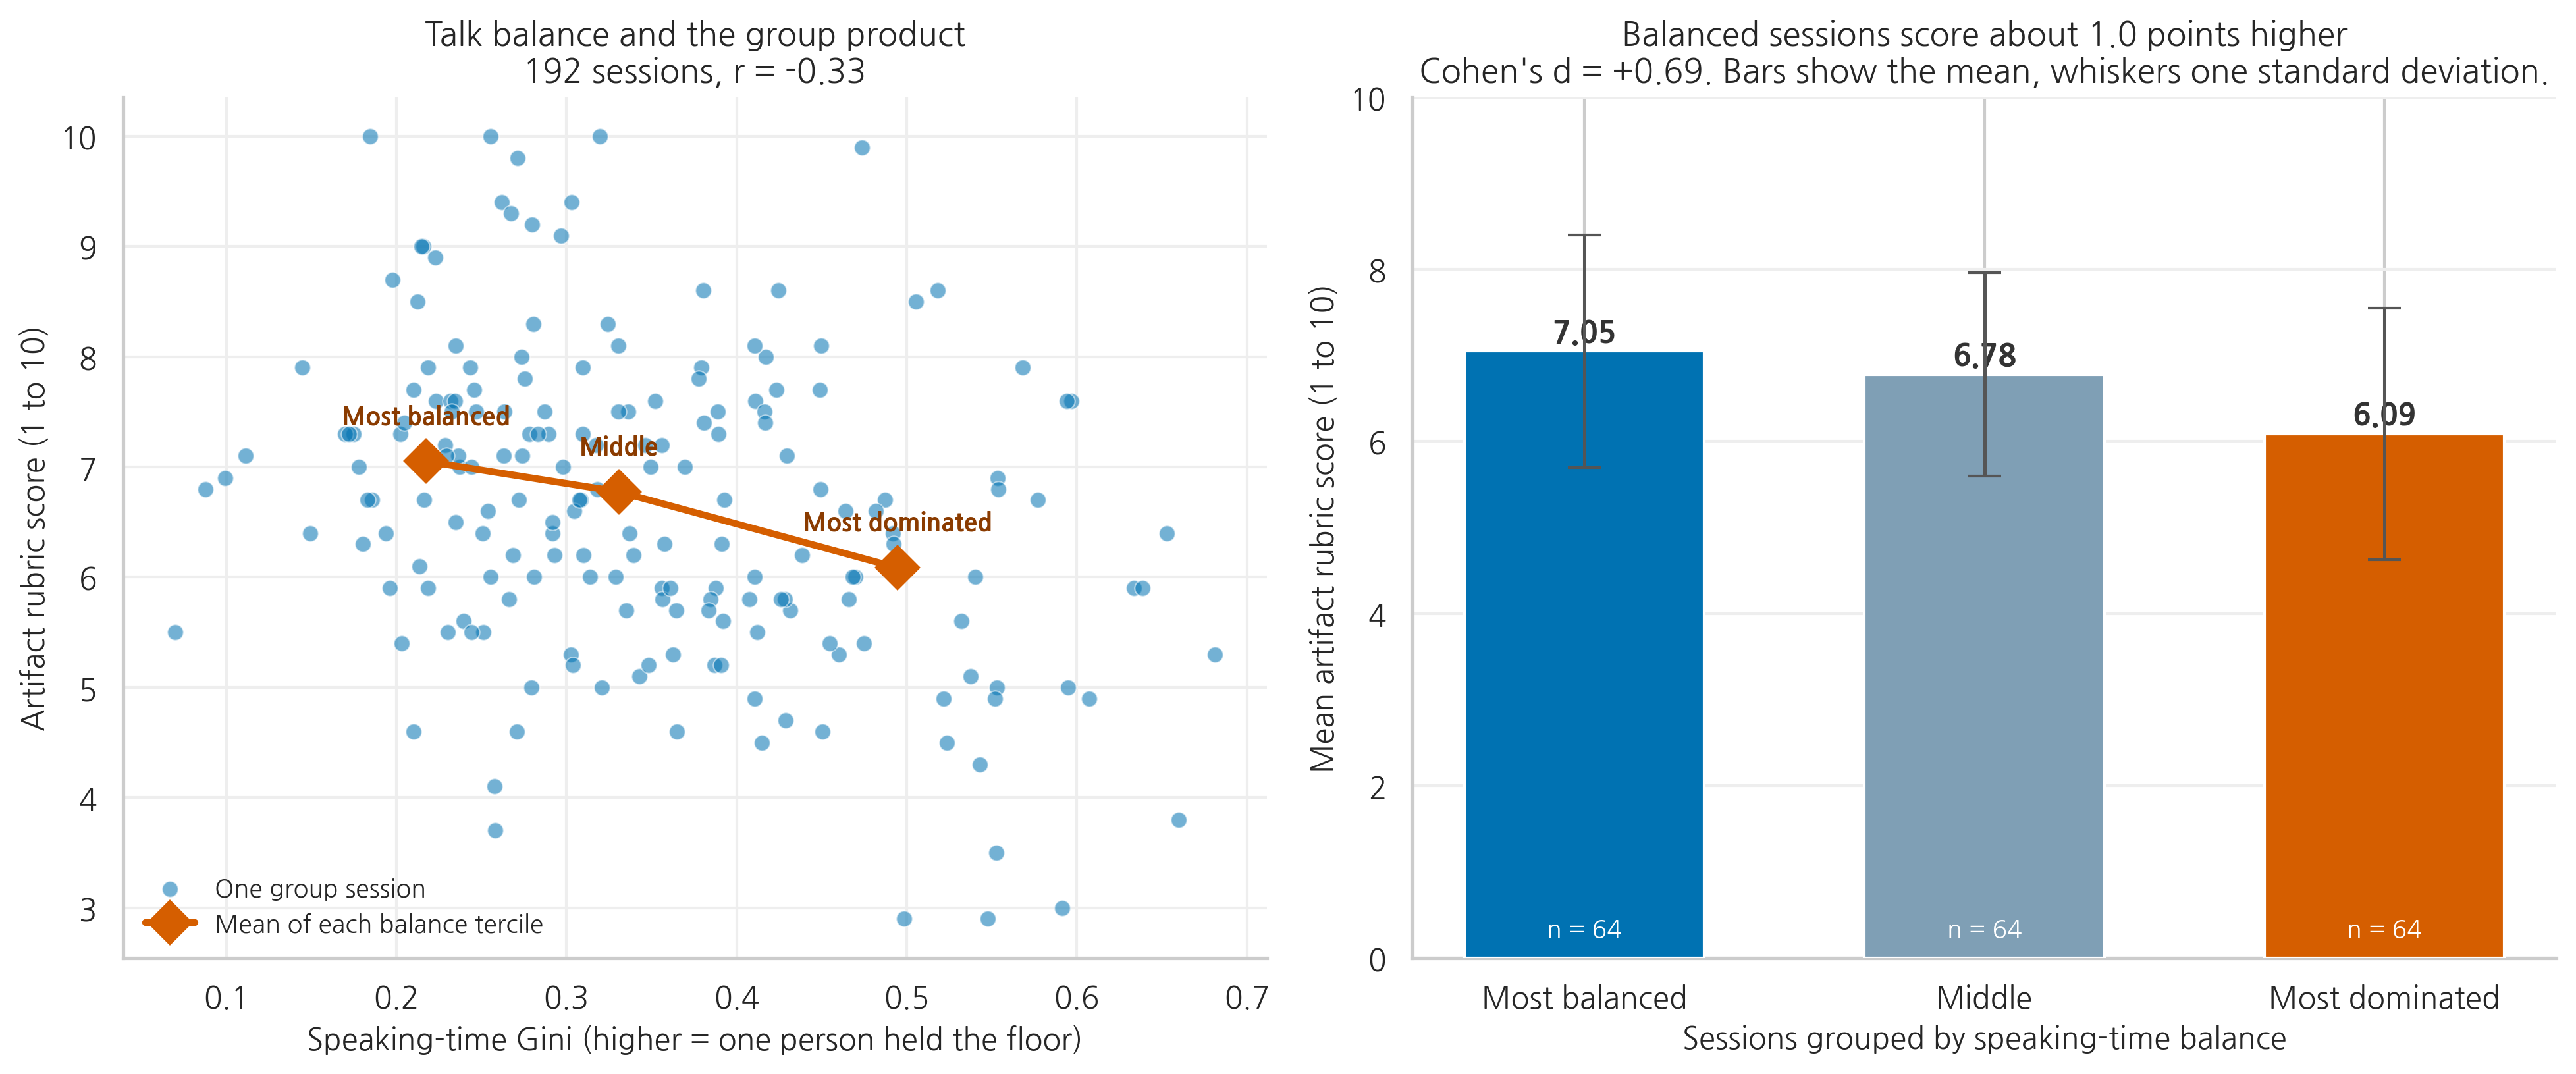

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))

ax = axes[0]
ax.scatter(sessions['talk_gini'], sessions['artifact_score'], s=34, color=BLUE,
           alpha=0.55, edgecolors='white', linewidths=0.5, label='One group session')
centres = sessions.groupby('balance_tercile', observed=True).agg(
    x=('talk_gini', 'mean'), y=('artifact_score', 'mean')).reset_index()
ax.plot(centres['x'], centres['y'], color=ORANGE, marker='D', markersize=11, linewidth=2.5,
        label='Mean of each balance tercile')
for _, c in centres.iterrows():
    ax.annotate(c['balance_tercile'], (c['x'], c['y']), xytext=(0, 14),
                textcoords='offset points', ha='center', fontsize=9,
                color='#8a3b00', fontweight='bold')
ax.set_xlabel('Speaking-time Gini (higher = one person held the floor)', fontsize=11)
ax.set_ylabel('Artifact rubric score (1 to 10)', fontsize=11)
ax.set_title(f'Talk balance and the group product\n192 sessions, r = {r:+.2f}', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc='lower left')

ax = axes[1]
order = ['Most balanced', 'Middle', 'Most dominated']
means = [tercile_tbl.loc[o, 'mean_artifact'] for o in order]
sds   = [tercile_tbl.loc[o, 'sd_artifact'] for o in order]
bars = ax.bar(order, means, yerr=sds, capsize=6, color=[BLUE, '#7f9fb5', ORANGE],
              width=0.6, zorder=3, error_kw=dict(ecolor='#555555', linewidth=1.2))
for bar, m, o in zip(bars, means, order):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.12, f'{m:.2f}',
            ha='center', fontsize=11, fontweight='bold', color='#333333')
    ax.text(bar.get_x() + bar.get_width() / 2, 0.25,
            f"n = {int(tercile_tbl.loc[o, 'n_sessions'])}", ha='center', fontsize=9, color='white')
ax.set_ylabel('Mean artifact rubric score (1 to 10)', fontsize=11)
ax.set_xlabel('Sessions grouped by speaking-time balance', fontsize=11)
ax.set_title(f"Balanced sessions score about {means[0] - means[2]:.1f} points higher\n"
             f"Cohen's d = {d_terciles:+.2f}. Bars show the mean, whiskers one standard deviation.",
             fontsize=12)
ax.set_ylim(0, 10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**💬 Interpret before moving on, and be careful here, because there are two traps stacked on top of each other.**

**Trap one: this is synthetic data.** The association between talk balance and artifact score is in this file because the person who wrote the generator put it there. That is not a scandal, it is what synthetic data is for, and it is also why no number in this section is evidence about real studios. What the section teaches is not that balance causes better products. It is what you would have to establish before you were allowed to say so.

**Trap two: even taking the file at face value, the relationship is modest and clustered.** The scatter is a cloud, not a line, the tercile bars overlap by a full standard deviation, and the group-level interval runs from -0.77 to -0.15.

So: suppose a colleague proposes a dashboard that alerts an instructor whenever a group's talk Gini crosses 0.5, on the theory that equalizing talk will raise artifact scores. Write down

1. two things that would have to be true for that intervention to work, at least one of which is about the group's task rather than the group's members;
2. one plausible alternative explanation for the pattern (what else might make a group both balanced and effective?);
3. and one thing the alert would do to the quietest person in a group on the day it fires.

### ✏️ Your turn 4: Gini on a different modality

Balance is not only about talk. Change `GINI_COLUMN` below to another modality and re-run: does inequality in that channel relate to the group product the same way?

Try `'idea_units_chat'`, `'doc_edits'`, or `'num_turns'`. One of these behaves very differently from the others, and noticing which is the point of the exercise.

One column in the list is a trap, and the cell prints a warning when you pick it. `gaze_peer_pct` is a bounded percentage that never comes near zero in this file, so its Gini measures "these five numbers are similar to each other", not "this was shared fairly". Section 6 said Gini needs a ratio scale with a real zero. This is the cell where that rule earns its keep.

In [21]:
# TODO: change this column and re-run.
GINI_COLUMN = 'speaking_time_s'

alt = (mmla.groupby(['group_id', 'session_id'])[GINI_COLUMN]
       .apply(gini).reset_index(name='gini_value')
       .merge(artifacts, on=['group_id', 'session_id']))

# Columns whose zero is not a real zero. A Gini on one of these is arithmetic,
# not an inequality measure, and the notebook says so rather than printing it plain.
NOT_RATIO_SCALED = {'gaze_peer_pct'}

r_alt = alt['gini_value'].corr(alt['artifact_score'])
print(f'Modality              : {LABELS[GINI_COLUMN]} ({GINI_COLUMN})')
print(f'Mean Gini per session : {alt["gini_value"].mean():.3f}')
print(f'Correlation with artifact score: r = {r_alt:+.2f}')
if GINI_COLUMN in NOT_RATIO_SCALED:
    lo_v, hi_v = mmla[GINI_COLUMN].min(), mmla[GINI_COLUMN].max()
    print()
    print(f'  !! CAUTION: {GINI_COLUMN} runs from {lo_v:.1f} to {hi_v:.1f} and never')
    print('     approaches zero, so it has no meaningful zero point. The Gini above')
    print('     is a real number and it is not an inequality. Do not report it.')
print()
print('For comparison, all seven modalities (the last column flags the ones where')
print('a Gini is not interpretable):')
for m in MODALITIES:
    a = (mmla.groupby(['group_id', 'session_id'])[m].apply(gini).reset_index(name='g')
         .merge(artifacts, on=['group_id', 'session_id']))
    note = '  <- not ratio-scaled, Gini not interpretable' if m in NOT_RATIO_SCALED else ''
    print(f'  {LABELS[m]:16s} mean Gini {a["g"].mean():.3f}   '
          f'r with artifact score {a["g"].corr(a["artifact_score"]):+.2f}{note}')

Modality              : Speaking time (speaking_time_s)
Mean Gini per session : 0.348
Correlation with artifact score: r = -0.33

For comparison, all seven modalities (the last column flags the ones where
a Gini is not interpretable):
  Speaking time    mean Gini 0.348   r with artifact score -0.33
  Turns            mean Gini 0.353   r with artifact score -0.33
  Gestures         mean Gini 0.245   r with artifact score -0.21
  Gaze at peers    mean Gini 0.087   r with artifact score -0.03  <- not ratio-scaled, Gini not interpretable
  Chat messages    mean Gini 0.238   r with artifact score +0.02
  Doc edits        mean Gini 0.366   r with artifact score -0.08
  Idea units       mean Gini 0.337   r with artifact score -0.08


## ✏️ 8. Stretch: build a fairer participation index and defend it

This section is the stretch goal. Everything above it is the core path, so if you are out of time, stop here, write the memo, and come back to this later.

Section 4 showed that ranking students by speaking time misplaces a specific, identifiable group of students. The obvious response is to stop using one modality and combine several. That is easy to compute and hard to justify, which is exactly why it is worth doing carefully.

The index below is deliberately simple: convert each modality to a percentile, take a weighted average, then re-rank. The default weights treat voice, ideas, and document work as equally important. **That is a value judgment, not a statistical finding.** Your job in the memo is to defend a set of weights, not to find the "correct" one.

Be clear about what a composite is and is not. **It is a choice about what the course will count as participation. It is not a correction to a broken measure.** Nothing about the microphone improves when you average it with the chat log. The composite does not recover contribution that the sensors missed, it re-weights what the sensors happened to record, and every student who was contributing in a way no sensor watched is still invisible in it. A composite that produces a proportionate flag rate has not become fair. It has become differently unfair, in a way you now have to defend by name.

In [22]:
# TODO (stretch): change these weights and re-run. They do not need to sum to 1;
# the function normalizes them for you. Setting a weight to 0 drops that modality.
WEIGHTS = {
    'speaking_time_s' : 1,
    'idea_units_chat' : 1,
    'doc_edits'       : 1,
}


def composite_percentile(df, weights):
    """Weighted average of percentile ranks, re-ranked to a 0-100 percentile."""
    total = sum(weights.values())
    blended = sum(df['pct_' + k] * w for k, w in weights.items()) / total
    return blended.rank(pct=True).mul(100)


profile['pct_voice_only'] = profile['pct_speaking_time_s']
profile['pct_composite']  = composite_percentile(profile, WEIGHTS)

FLAG_CUT = 25  # "low participation" = bottom quartile of the class

rows = []
for label, col in [('Voice only (speaking time)', 'pct_voice_only'),
                   ('Composite index', 'pct_composite')]:
    flagged = profile[col] <= FLAG_CUT
    rows.append({
        'index': label,
        'students flagged low': int(flagged.sum()),
        'multilingual among flagged': int(profile.loc[flagged, 'multilingual'].sum()),
        'share of the 24 multilingual students flagged':
            f"{profile.loc[flagged, 'multilingual'].sum() / profile['multilingual'].sum():.0%}",
        'mean percentile, multilingual': round(profile.loc[profile['multilingual'] == 1, col].mean(), 1),
        'mean percentile, everyone else': round(profile.loc[profile['multilingual'] == 0, col].mean(), 1),
    })

comparison = pd.DataFrame(rows).set_index('index').T
print(f'Weights used: {WEIGHTS}')
print(f'"Low participation" defined as the bottom {FLAG_CUT} percent of the class.\n')
print(comparison.to_string())

Weights used: {'speaking_time_s': 1, 'idea_units_chat': 1, 'doc_edits': 1}
"Low participation" defined as the bottom 25 percent of the class.

index                                         Voice only (speaking time) Composite index
students flagged low                                                  30              30
multilingual among flagged                                            11               5
share of the 24 multilingual students flagged                        46%             21%
mean percentile, multilingual                                       35.9            55.1
mean percentile, everyone else                                      54.0            49.2


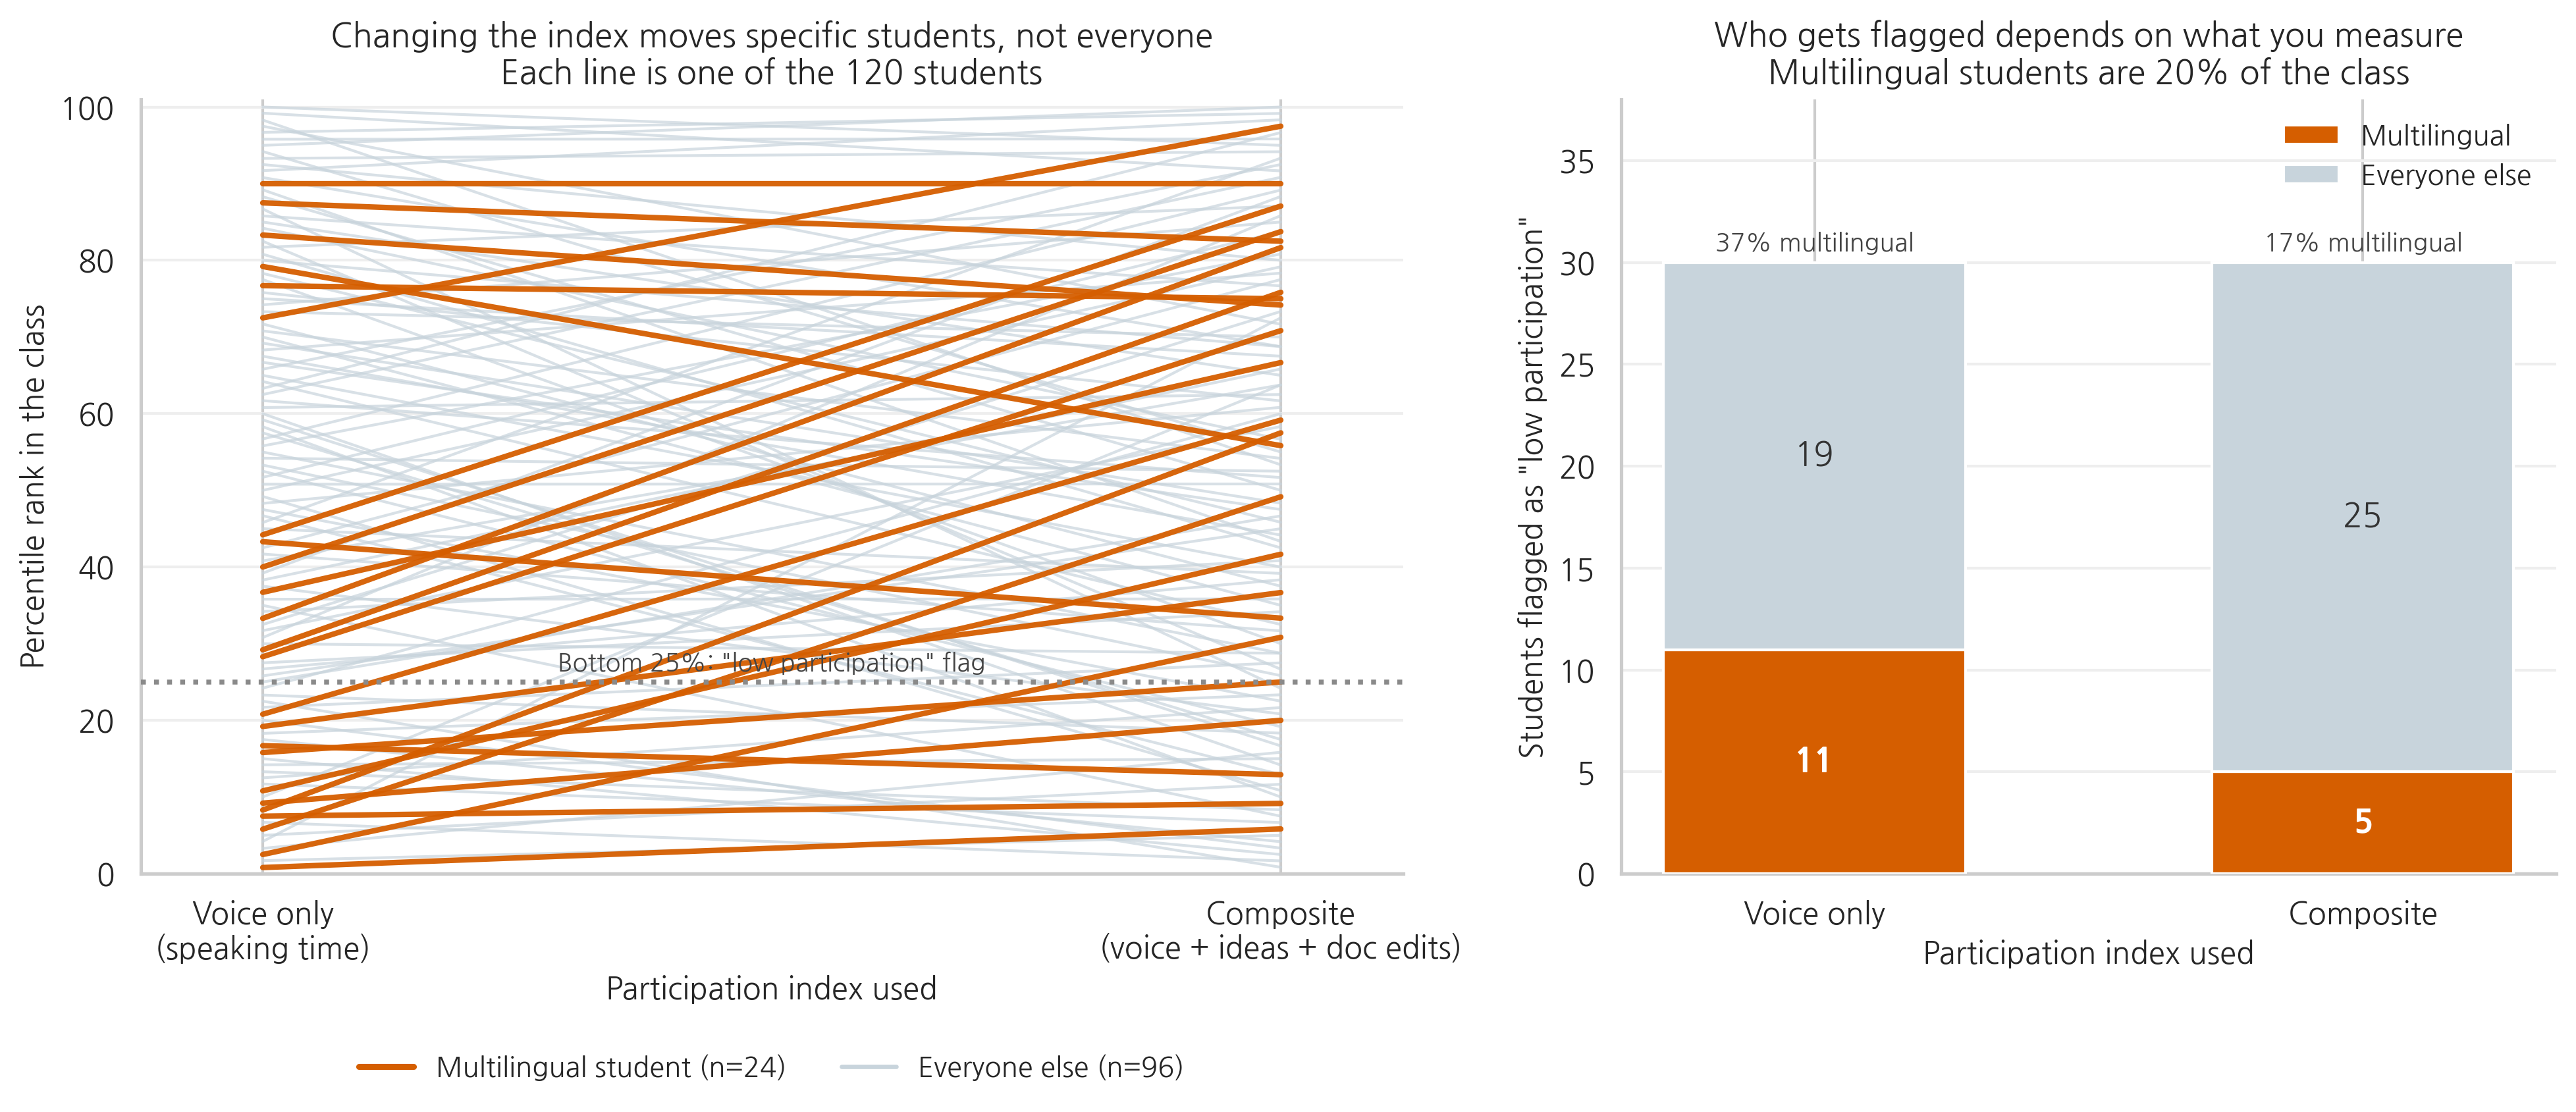

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.0),
                         gridspec_kw={'width_ratios': [1.35, 1]})

ax = axes[0]
for _, row in profile.iterrows():
    is_ml = row['multilingual'] == 1
    ax.plot([0, 1], [row['pct_voice_only'], row['pct_composite']],
            color=ORANGE if is_ml else '#c8d4dc',
            linewidth=2.0 if is_ml else 1.0,
            alpha=0.95 if is_ml else 0.7,
            zorder=3 if is_ml else 1)
ax.axhline(FLAG_CUT, color=GREY, linestyle=':', linewidth=1.8, zorder=4)
ax.text(0.5, FLAG_CUT + 1.5, f'Bottom {FLAG_CUT}%: "low participation" flag',
        ha='center', fontsize=9, color='#444444')
ax.plot([], [], color=ORANGE, linewidth=2.2, label='Multilingual student (n=24)')
ax.plot([], [], color='#c8d4dc', linewidth=1.6, label='Everyone else (n=96)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Voice only\n(speaking time)', 'Composite\n(voice + ideas + doc edits)'], fontsize=11)
ax.set_xlim(-0.12, 1.12)
ax.set_ylim(0, 101)
ax.set_ylabel('Percentile rank in the class', fontsize=11)
ax.set_xlabel('Participation index used', fontsize=11)
ax.set_title('Changing the index moves specific students, not everyone\n'
             'Each line is one of the 120 students', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10, loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=2)

ax = axes[1]
labels = ['Voice only', 'Composite']
ml_flagged = [int(profile.loc[profile['pct_voice_only'] <= FLAG_CUT, 'multilingual'].sum()),
              int(profile.loc[profile['pct_composite'] <= FLAG_CUT, 'multilingual'].sum())]
other_flagged = [int((profile['pct_voice_only'] <= FLAG_CUT).sum()) - ml_flagged[0],
                 int((profile['pct_composite'] <= FLAG_CUT).sum()) - ml_flagged[1]]
xpos = np.arange(2)
b1 = ax.bar(xpos, ml_flagged, width=0.55, color=ORANGE, label='Multilingual', zorder=3)
b2 = ax.bar(xpos, other_flagged, bottom=ml_flagged, width=0.55, color='#c8d4dc',
            label='Everyone else', zorder=3)
for x, ml, ot in zip(xpos, ml_flagged, other_flagged):
    ax.text(x, ml / 2, str(ml), ha='center', va='center', fontsize=12,
            fontweight='bold', color='white')
    ax.text(x, ml + ot / 2, str(ot), ha='center', va='center', fontsize=12, color='#333333')
    ax.text(x, ml + ot + 0.6, f'{ml / (ml + ot):.0%} multilingual', ha='center', fontsize=9,
            color='#444444')
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Students flagged as "low participation"', fontsize=11)
ax.set_xlabel('Participation index used', fontsize=11)
ax.set_ylim(0, 38)
ax.set_title('Who gets flagged depends on what you measure\n'
             'Multilingual students are 20% of the class', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

**💬 Interpret before moving on.** The composite is not automatically the fairer measure. It buys a more proportionate flag rate at a price: it is harder to explain to a student, it assumes chat and speech are interchangeable evidence of contribution, and it can be gamed by anyone who learns the weights. Notice too that the flag itself did not move: thirty students sit below the line under either index. **The composite changed who is standing in the bottom quartile, not whether a bottom quartile gets a label.** If the label carries a consequence, someone still receives it.

Four questions to answer in your memo:

1. Which modalities did you include, and what claim about learning justifies each one? (Not "it was available".)
2. Who moves when you change the weights, and can you name them? Look at the lines that cross in the left panel.
3. What would you tell a student who asks why their participation number changed?
4. Is there a version of this where the honest recommendation is that no index should be computed at all? Write the strongest case for it before you decide against it.

## 💬 9. Reflection: tie it to the readings

Answer these in the markdown cell below (double-click it to type). Two to four sentences each is plenty. These are the notes you will draw on for the memo.

**1. Ochoa (2022).** Ochoa lays out the MMLA pipeline from raw signal to interpretation and is explicit that each stage is a modeling choice. Pick one column you used this week and trace it backwards: what physical signal produced it, what had to be decided to turn that signal into a number, and what got discarded on the way?

**2. Worsley, Martinez-Maldonado, and D'Angelo (2021).** Their twelve commitments argue that MMLA should be accountable to the people it senses, not only to the sensors. Choose the commitment that your analysis this week strained the most. What would you have to change about the study design (not the code) to meet it?

**3. Lee, Sung, Celedón-Pattichis, and Pattichis (2026).** This study examines multimodal participation dynamics by gender and linguistic diversity, and argues for an inclusive reading of collaborative participation. Where did your findings echo that argument, and where did your data push back or stay silent?

**4. Mohammadi and colleagues (2025).** Their review maps how AI is being used across MMLA. Given what you saw this week about a single modality misrepresenting a group of students, what would you require of an automated multimodal participation system before letting it inform a grade?

**5. Your own context.** In the setting you care about (your dissertation site, your classroom, your program), which modality is currently standing in for "participation", and who does that choice serve well?

### ✍️ Your reflection

*Double-click this cell to edit it. Delete this line and write here.*

**1. Ochoa (2022):**

**2. Worsley, Martinez-Maldonado, and D'Angelo (2021):**

**3. Lee, Sung, Celedón-Pattichis, and Pattichis (2026):**

**4. Mohammadi et al. (2025):**

**5. Your own context:**

## 📝 10. Deliverable: the inclusive participation memo

Write a memo of about 500 to 700 words in the cell below, addressed to the instructor of EDUC 1010, who has asked you a plain question: **"Can I use the studio sensor data to give a participation grade?"**

Your memo must:

1. **Report what you found.** Use at least two figures or tables from this notebook by name and give the actual numbers, including at least one effect size and the Gini result.
2. **Name the measurement problem.** Explain, in language a colleague without a statistics background can follow, why speaking time alone would misrepresent a specific group of students in this class, and roughly how many students that is.
3. **Take a position on the group-level finding.** Balanced talk goes with better artifacts. Say what that does and does not license the instructor to do, and name at least one alternative explanation.
4. **Make a recommendation you can live with.** Either a defensible participation measure (say what goes in it and why), or a defensible refusal (say what you would use instead, and why sensors are the wrong tool for this decision). A clear refusal, well argued, earns full credit.
5. **State the limits.** These data are synthetic, the group size is five, gaze and gesture come from imperfect models, and "idea units" were coded by a process you did not see. Say which limit worries you most and why.

Anchor the argument in the readings by author name. Do not fabricate page numbers or quotations.

### 📄 Inclusive Participation Memo

*Double-click to edit. Replace this text with your memo (about 500 to 700 words).*

**To:** Instructor, EDUC 1010
**From:** [your name]
**Date:** September 30, 2026
**Re:** Using studio sensor data to assess participation

**What the data show**

**Where a single modality misleads**

**What the group-level pattern does and does not license**

**Recommendation**

**Limits**

## ✅ 11. Submission checklist

Mini Project 3 is due this week on Canvas. Submit **three things**:

- [ ] **This notebook**, run top to bottom with all outputs visible. In Colab: `File > Download > Download .ipynb`, then upload to the Canvas assignment "Mini Project 3". Name it `LastName_MiniProject3.ipynb`.
- [ ] **The inclusive participation memo** (section 10), either inside the notebook cell or as a separate document, 500 to 700 words.
- [ ] **Your AI interaction log plus reflection**, in the Canvas "AI Reflection" submission. See the reminder below for which part goes where.

Before you submit, confirm:

- [ ] `Runtime > Restart session and run all` finishes with no errors.
- [ ] Every figure in your submitted notebook has a title and labeled axes (including any you added).
- [ ] You answered every 💬 interpretation prompt, not only the ones that were easy.
- [ ] Section 9 reflection is complete and names the authors.
- [ ] Numbers quoted in your memo match the numbers printed in your notebook.

**Also due this week:** the **Mid-Semester Check-In**, a separate short Canvas submission. It is not part of Mini Project 3 and it is not graded on quality. It is how the second half of the course gets adjusted to the people actually in the room, so please answer it honestly.

### 🤖 AI documentation reminder

Course policy: **AI use is permitted in designated activities and must be documented.** If you used a chatbot or coding assistant for any part of this project (debugging, wording, statistics, interpretation), the policy asks for two separate pieces, submitted in two different places:

**1. The conversation record goes in a Word file.** Export every relevant exchange, across every session and every tool you used, paste it into a Word document, and attach that file to the Canvas "AI Reflection" submission. Do not paste your transcript into the Canvas text box.

**2. The reflection goes in the Canvas text box.** Copy these four questions into the box and answer each one:

1. How did you use it?
2. Did AI help you with your work this week? If so, how?
3. Did it make your work more challenging in any way? If so, how?
4. What new lesson or lessons, if any, could you share with a friend (or the class) that summarize what you learned about AI through this week's work?

Two specific things worth reflecting on this week: if an AI tool told you something about Gini coefficients or effect sizes, say how you checked it, and if you accepted a suggested interpretation of the multilingual comparison, say what made it persuasive.

You are not graded on how much or how little you used AI. You are graded on the rubric and on the quality of your final product. Undisclosed AI use is an Honor Code violation. Disclosed use is normal scholarly practice, and in a course about analytics it is also a data point about your own learning process.


## 📎 Appendix: solutions to the ✏️ Your turn cells

Try each one before you read the answer. These are not the only right answers, they are worked examples.

**Your turn 1 (profile two other students).** `S015` (Yuki, group G10) sits at the 4th percentile on speaking time and the 90th on idea units, alongside `S083` (Kenji), who is at the 96th on speaking time. The shape of the contrast is the same as Solveig and Mikael, which is the point: this is not one unusual student.

**Your turn 2 (a different group).** In `G10`, four of five students sit above the 49th percentile on doc edits and three sit above the 69th, while the group's mean talk Gini is 0.45, well into the top third for concentration. It still averages 7.98 on artifacts against a class mean of 6.64. That single group does not overturn the Section 7 pattern, and it is the reminder that the pattern is a tendency across 24 groups, not a rule any one group obeys. A group can be uneven on the microphone and produce good work.

**Your turn 3 (disaggregate by first_gen).** Every `first_gen` effect size is between -0.24 and +0.03 and **every one of the seven intervals contains zero**. State that the way it should be stated: this file cannot show a first-generation difference on any of these seven channels. That is not the same sentence as "there is no difference", and the difference between those two sentences is most of what a limitations section is for. With 36 first-generation students, a real gap of a third of a standard deviation would very often go undetected here.

What you can say is comparative and it is enough: whatever is happening in this class shows up on the multilingual split and not on this one.

**Your turn 4 (Gini on another modality).** `num_turns` behaves like speaking time, which is unsurprising: they are two readings of the same microphone. Inequality in `idea_units_chat`, `doc_edits`, and `chat_messages` relates only weakly to artifact score in this file.

Two cautions before you write that up.

First, `gaze_peer_pct` is the trap. Its Gini is 0.087, which looks like a beautifully equal group and is really just an artifact of a percentage that never leaves the range 17 to 61. A variable with no meaningful zero has no meaningful Gini. The cell prints a warning when you select it.

Second, and larger: **the association between speaking-time balance and artifact score is in this file because the generator put it there.** Nothing you find here is evidence about real studios. The transferable statement is conditional, and it is the one to put in the memo: *if* a relationship like this held in a real course, a dashboard built on chat inequality would be measuring something real that does not predict this particular outcome, and you would still need a study that did not create its own answer before acting on it.

**Stretch (weights).** There is no correct answer, only defensible ones. Two arguments worth having: (a) weighting speaking time lower is a fairness gain for students who contribute in text, but it also lowers the visibility of students who do the hard interactional work of managing a group out loud; (b) any weighting scheme is a statement about what counts as contribution in your course, so it should match the learning goals you actually assess, not the sensors you happen to own.

Run the cell below to see the worked versions.

In [24]:
# Worked solutions. Run this cell to compare with your own answers.

print('=' * 78)
print('Your turn 1: a second pair of students')
print('=' * 78)
sol = profile[profile['student_id'].isin(['S015', 'S083'])][['student_id', 'first_name', 'group_id'] + PCT_COLS]
sol.columns = ['id', 'first', 'group'] + [LABELS[m] for m in MODALITIES]
print(sol.to_string(index=False))

print()
print('=' * 78)
print('Your turn 3: disaggregating by first_gen instead of multilingual')
print('=' * 78)
print(modality_gaps(profile, 'first_gen').to_string(index=False))
print()
print('Compare with the multilingual version:')
print(modality_gaps(profile, 'multilingual')[['modality', "Cohen's d"]].to_string(index=False))

print()
print('=' * 78)
print('Your turn 4: Gini of every modality against artifact score')
print('=' * 78)
for m in MODALITIES:
    a = (mmla.groupby(['group_id', 'session_id'])[m].apply(gini).reset_index(name='g')
         .merge(artifacts, on=['group_id', 'session_id']))
    print(f'  {LABELS[m]:16s} mean Gini {a["g"].mean():.3f}   r with artifact {a["g"].corr(a["artifact_score"]):+.2f}')

print()
print('=' * 78)
print('Stretch: three weighting schemes compared')
print('=' * 78)
schemes = {
    'voice only'                    : {'speaking_time_s': 1},
    'voice + ideas'                 : {'speaking_time_s': 1, 'idea_units_chat': 1},
    'voice + ideas + doc edits'     : {'speaking_time_s': 1, 'idea_units_chat': 1, 'doc_edits': 1},
    'all seven modalities equally'  : {m: 1 for m in MODALITIES},
}
out = []
for name, w in schemes.items():
    p = composite_percentile(profile, w)
    flagged = p <= FLAG_CUT
    out.append({'scheme': name,
                'multilingual flagged (of 24)': int(profile.loc[flagged, 'multilingual'].sum()),
                'mean percentile, multilingual': round(p[profile['multilingual'] == 1].mean(), 1),
                'mean percentile, others': round(p[profile['multilingual'] == 0].mean(), 1)})
print(pd.DataFrame(out).to_string(index=False))

Your turn 1: a second pair of students
  id first group  Speaking time  Turns  Gestures  Gaze at peers  Chat messages  Doc edits  Idea units
S015  Yuki   G10            4.2    4.2       6.7            5.8           46.7       93.3        89.6
S083 Kenji   G10           95.8   90.8      98.3           90.4           70.4       69.6        74.6

Your turn 3: disaggregating by first_gen instead of multilingual
     modality                  stream  mean if first_gen=1  mean if first_gen=0  Cohen's d         95% CI CI excludes 0       _lo      _hi
    Doc edits digital (workspace log)                 3.49                 4.04      -0.24 [-0.62, +0.15]            no -0.619621 0.146733
Gaze at peers      video (gaze model)                38.14                38.78      -0.17 [-0.55, +0.21]            no -0.553811 0.211431
     Gestures      video (pose model)                13.08                13.64      -0.11 [-0.50, +0.27]            no -0.495350 0.269200
Chat messages digital (workspace 

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

*All data in this notebook are synthetic. Course design and data universe by Dr. Hakeoung Hannah Lee.*